In [1]:
%load_ext autoreload
%autoreload 2
#import qRegNN_NFs as qrnn
#from trainingTools_QR import NFTrainer
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
from trainingTools import NFTrainer
import qRegNN_NFs_general_simultaneous as qrnn
import sklearn
import scipy
import sklearn.datasets as datasets

/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
rangeScale = 3

btrain,l1 = datasets.make_moons(100000,noise=0.02)
btest,l2 = datasets.make_moons(20000,noise=0.02)

dtrain,l2 = datasets.make_moons(100000,noise=0.02)
dtest,l2 = datasets.make_moons(20000,noise=0.02)
dtrain[:,1] *= 0.75
dtest[:,1] *= 0.75

#plt.scatter(btrain[:,0],btrain[:,1],s=2)
#plt.scatter(dtrain[:,0],dtrain[:,1],s=2)

In [11]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3,"hidden_features":40,
             "num_layers":4,"num_bins":20,"num_blocks_per_layer":4,"tails":"linear"}
rangeScale = 3
trainer = qrnn.chainedNFTrainer(btrain,btest,dtrain,dtest,['x','y'],control=[0],NF_kwargs=NF_kwargs,rangeScale=rangeScale)

RUNNING TRAININGS
Training flow bkgFlow_step0_y


Loss: -0.23165908455848694:  45%|████▍     | 1341/3000 [01:43<02:07, 12.99it/s] 


Training flow dataFlow_step0_y


Loss: -0.26352155208587646:  32%|███▏      | 964/3000 [01:14<02:37, 12.93it/s]  


CORRECTING BKG


100%|██████████| 3/3 [00:00<00:00, 16.67it/s]


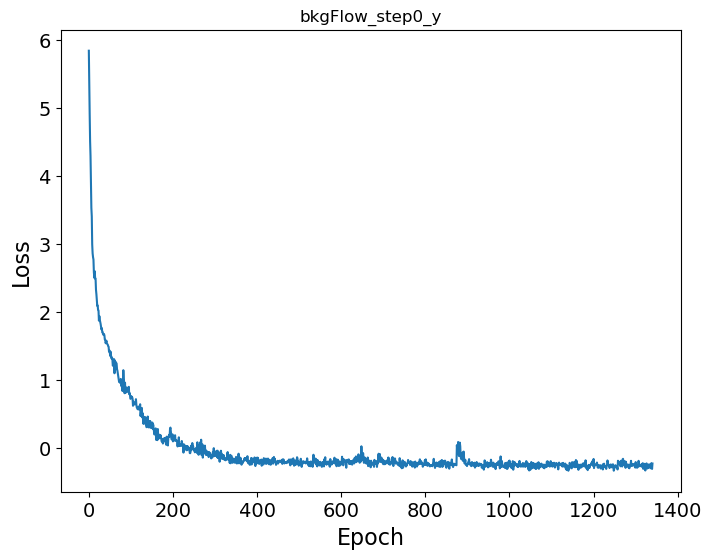

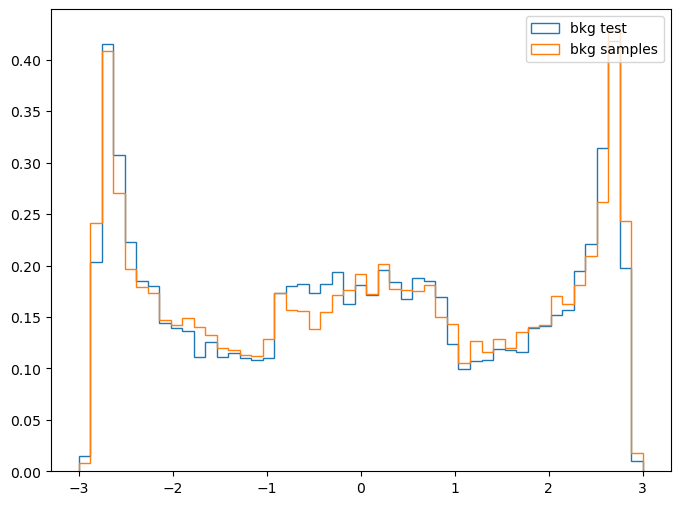

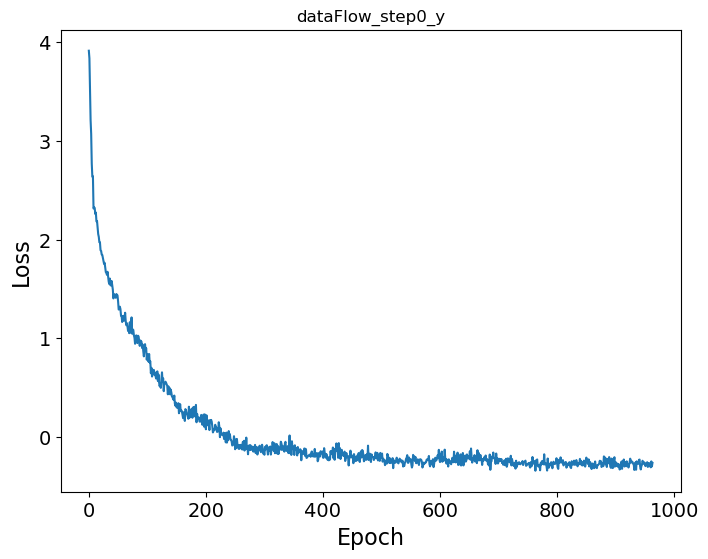

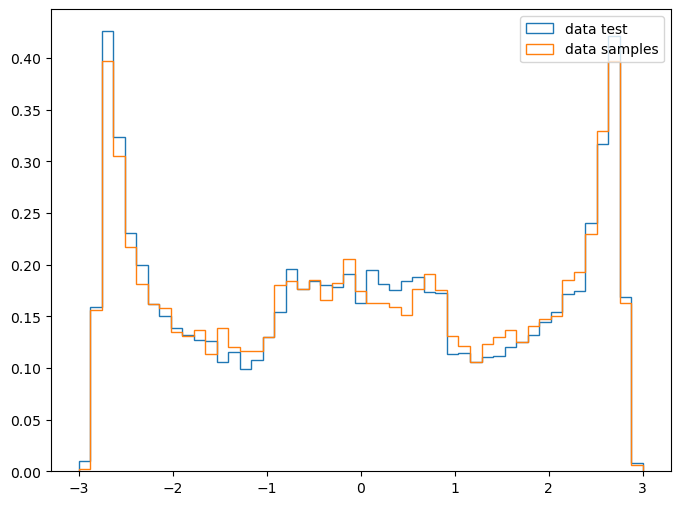

In [12]:
trainer.runAll(patience=200,learning_rate=5e-4,n_epoch=3000,bs=1024,print_interval=100)

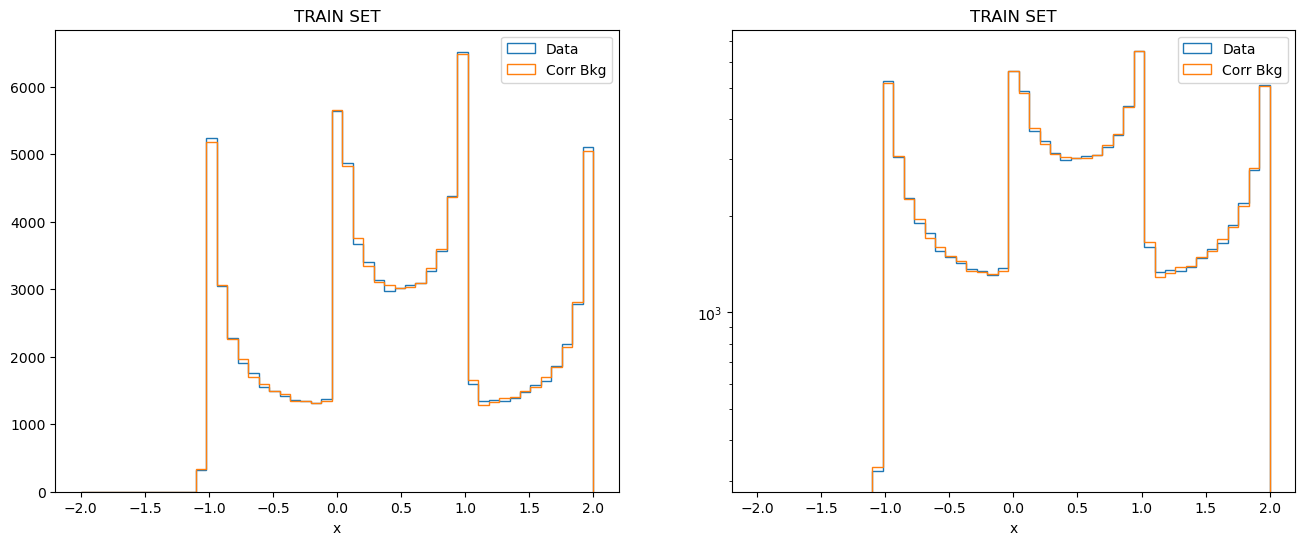

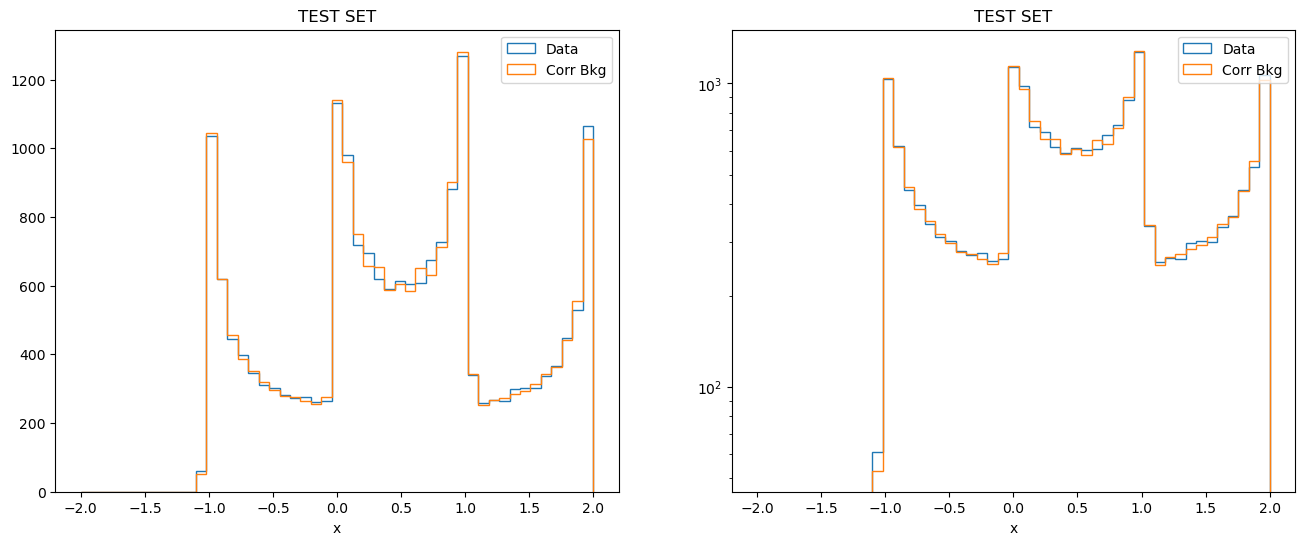

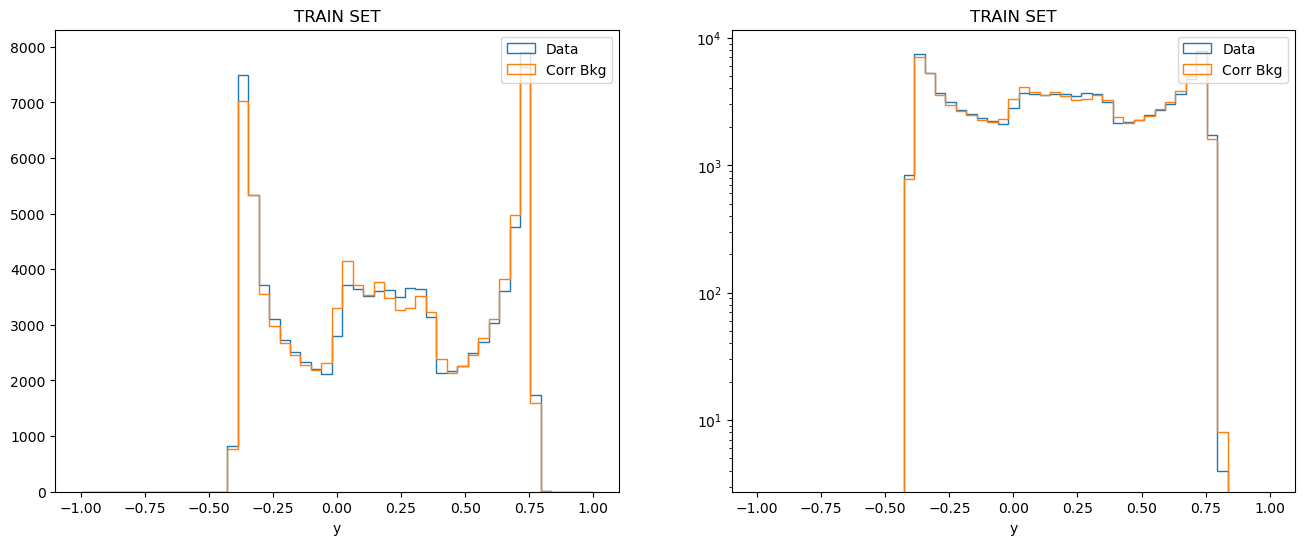

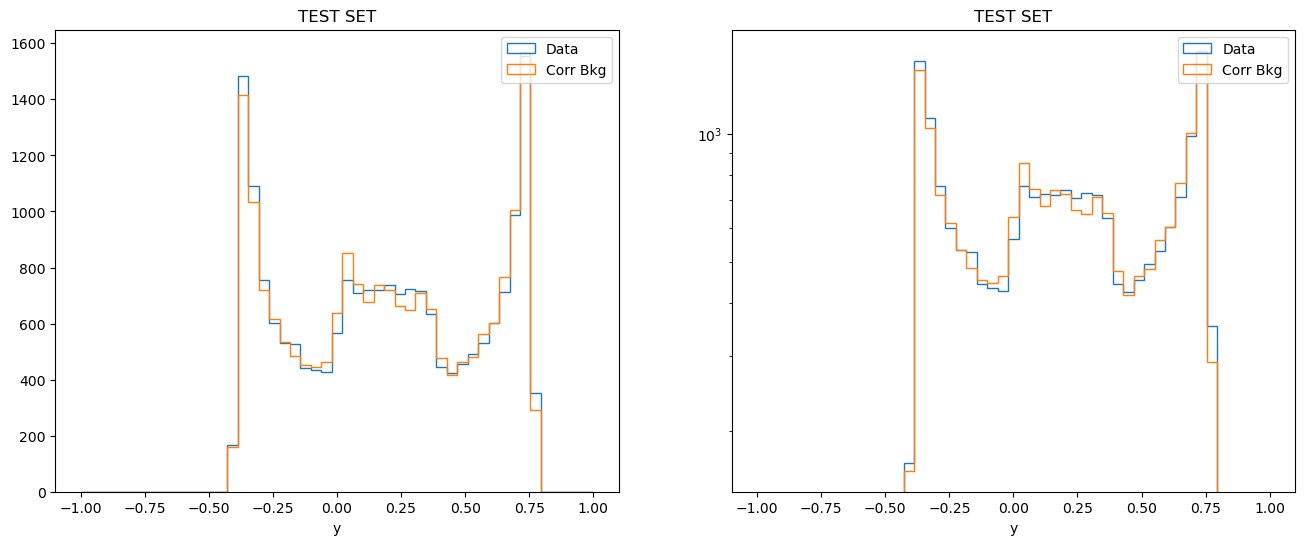

In [13]:
trainer.plotAll([np.linspace(-2,2,50),np.linspace(-1,1,50)])

In [14]:
bkg,_ = datasets.make_moons(10000,noise=0.02)
data,_ = datasets.make_moons(10000,noise=0.02)
data[:,1] *= 0.75
data,bkg_corr,variables = trainer.correctFull(data,bkg)
d = np.concatenate([data[v] for v in variables],axis=1)
b = np.concatenate([bkg_corr[v] for v in variables],axis=1)

100%|██████████| 2/2 [00:00<00:00, 27.72it/s]


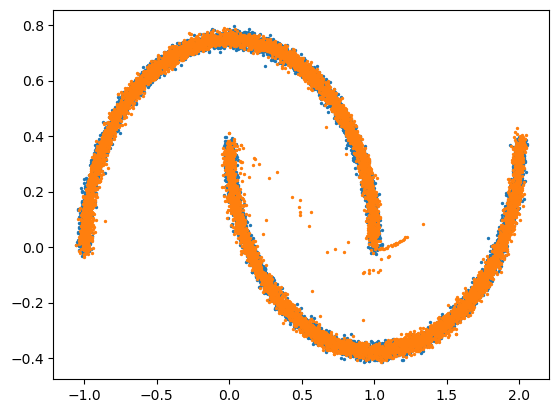

In [15]:
plt.scatter(d[:,0],d[:,1],s=2)
plt.scatter(b[:,0],b[:,1],s=2)

# skewed moons

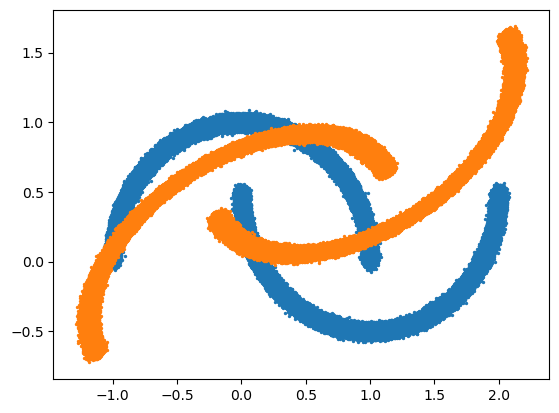

In [3]:
btrain,l1 = datasets.make_moons(1000000,noise=0.02)
btest,l2 = datasets.make_moons(20000,noise=0.02)

dtrain,l2 = datasets.make_moons(1000000,noise=0.02)
dtest,l2 = datasets.make_moons(20000,noise=0.02)
dtrain[:,0] *= 1.3
dtrain[:,1] *= 0.75
dtest[:,0] *= 1.3
dtest[:,1] *= 0.75
theta = 30*np.pi/180
rot = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])
dtrain = rot.dot(dtrain.T).T
dtest = rot.dot(dtest.T).T

plt.scatter(btrain[:,0],btrain[:,1],s=2)
plt.scatter(dtrain[:,0],dtrain[:,1],s=2)

In [68]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.2,"hidden_features":160,
             "num_layers":1,"num_bins":80,"num_blocks_per_layer":4,"tails":"linear"}
rangeScale = 3
trainer = qrnn.chainedNFTrainer(btrain,btest,dtrain,dtest,['x','y'],NF_kwargs=NF_kwargs,rangeScale=rangeScale)

RUNNING TRAININGS
Training flow bkgFlow_step0_x


Loss: 1.6349879503250122: 100%|██████████| 4000/4000 [07:13<00:00,  9.22it/s]


Training flow dataFlow_step0_x


Loss: 1.6062228679656982: 100%|██████████| 4000/4000 [07:26<00:00,  8.96it/s]


CORRECTING BKG


...

Loss: -0.31364139914512634: 100%|██████████| 4000/4000 [07:45<00:00,  8.60it/s]  


Training flow dataFlow_step1_y


Loss: -0.8282557129859924: 100%|██████████| 4000/4000 [07:26<00:00,  8.97it/s] 


CORRECTING BKG


100%|██████████| 3/3 [00:00<00:00, 41.71it/s]


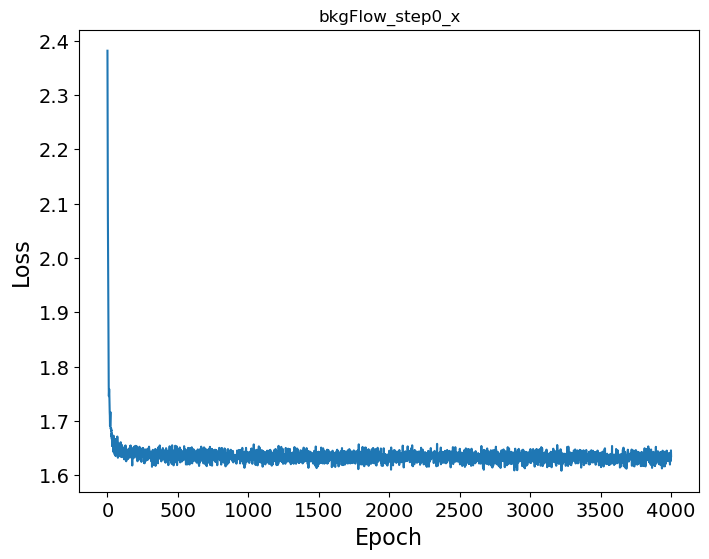

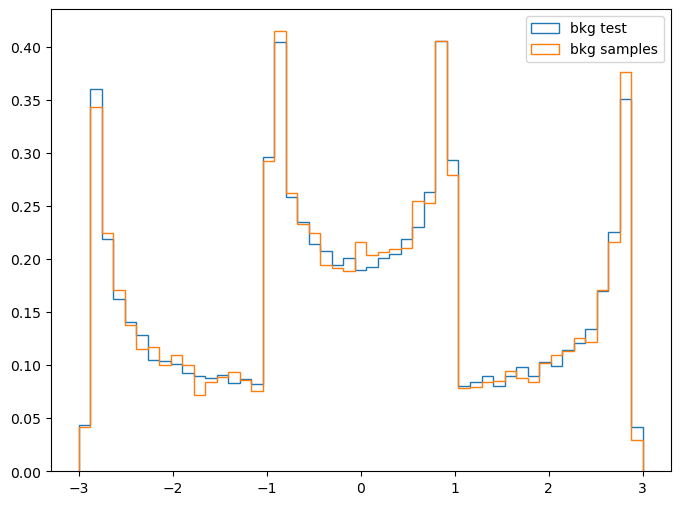

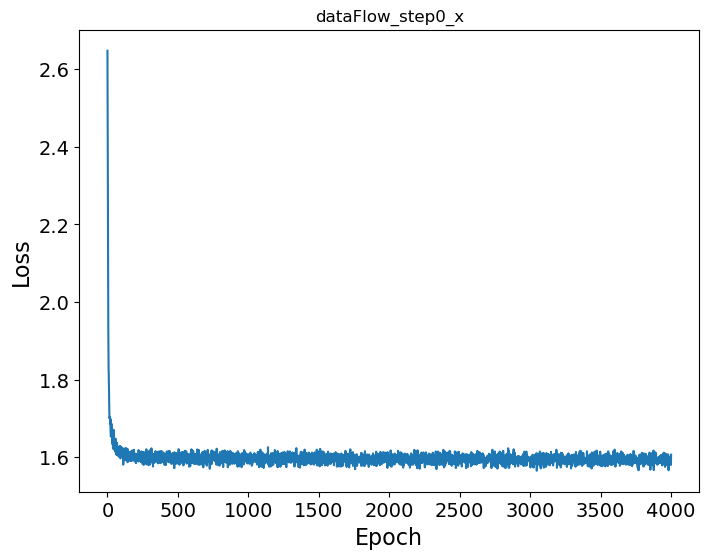

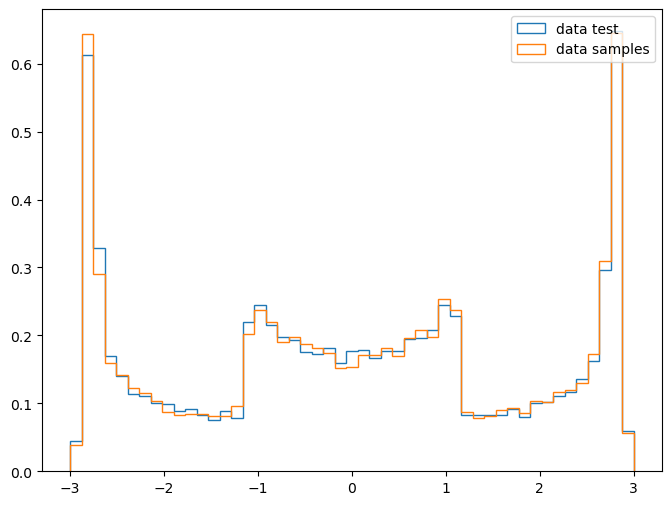

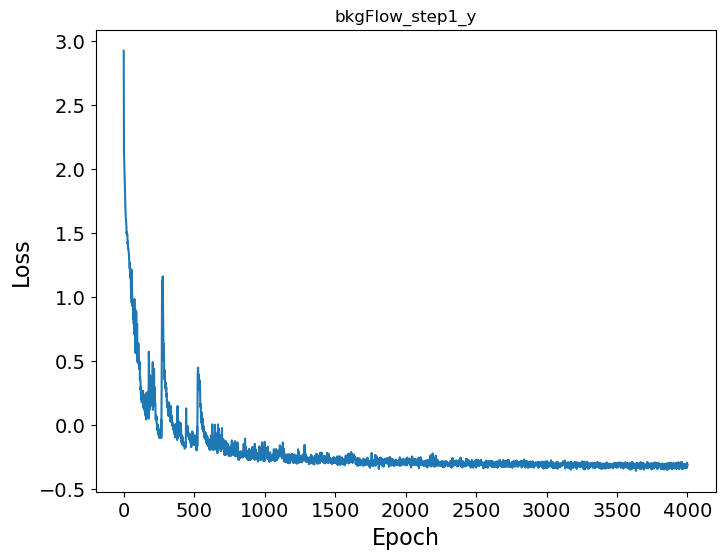

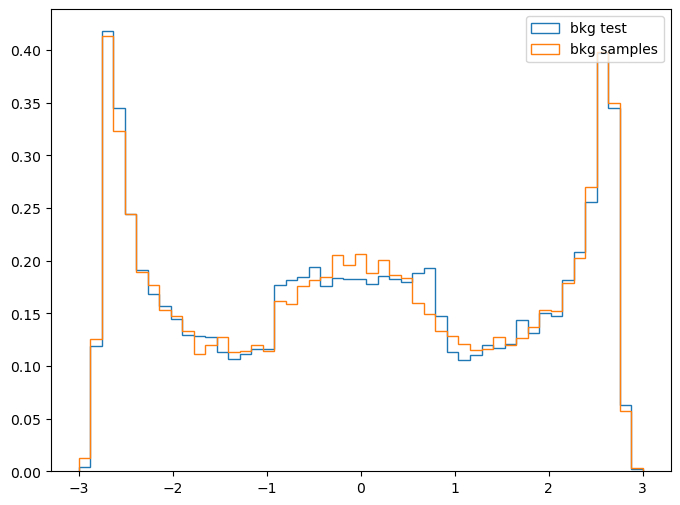

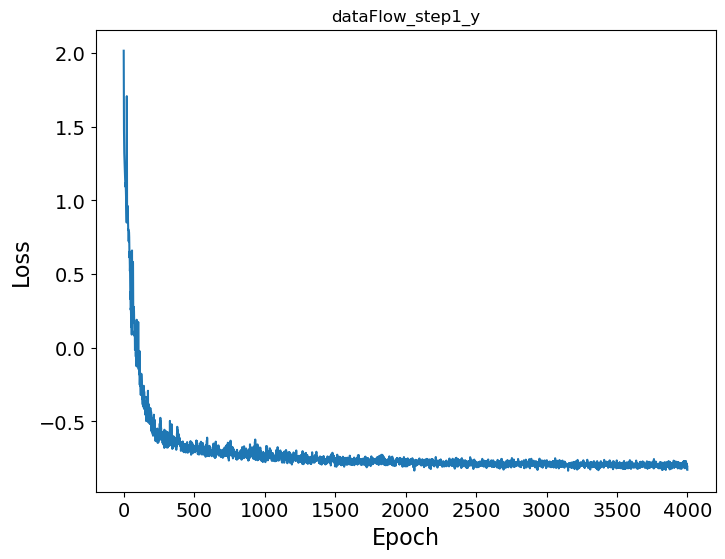

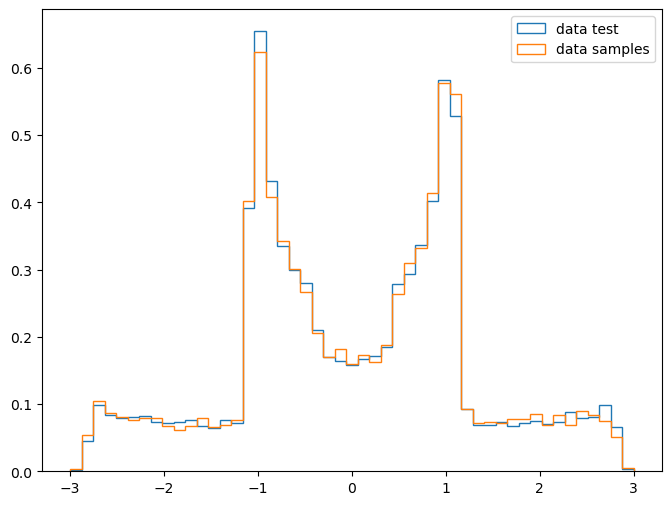

In [69]:
trainer.runAll(patience=10000,n_epoch=4000,learning_rate=5e-4,bs=5000)

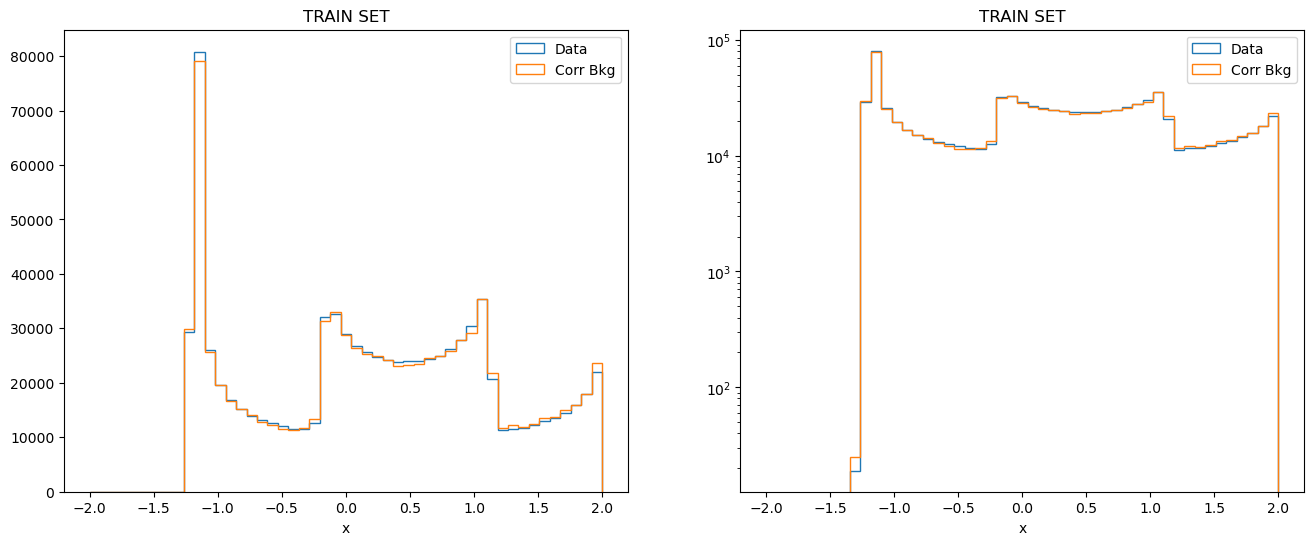

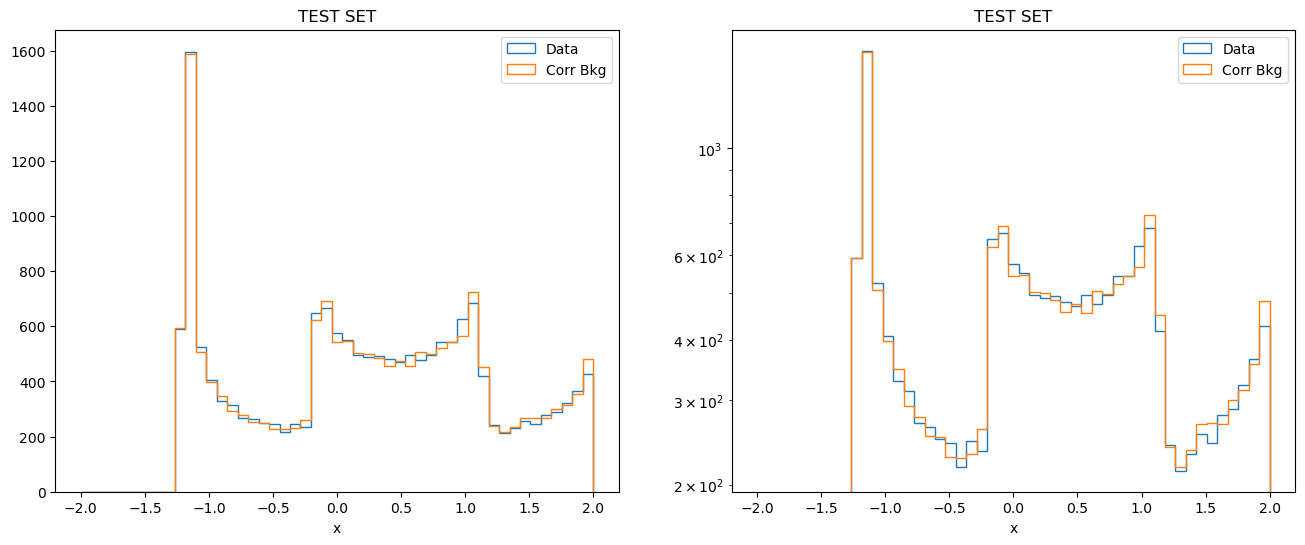

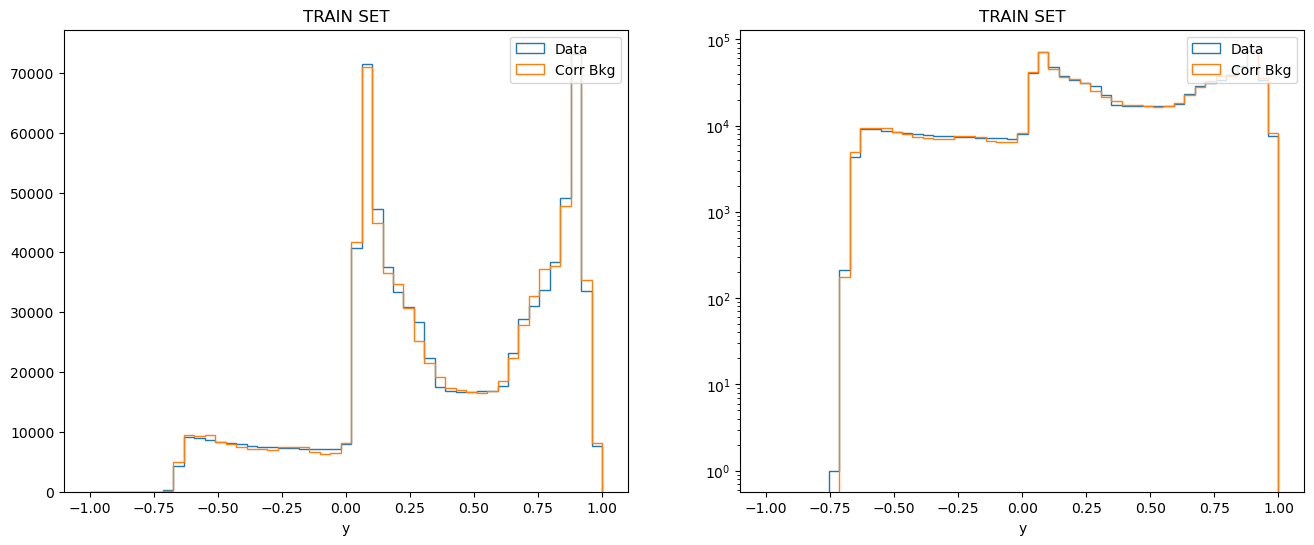

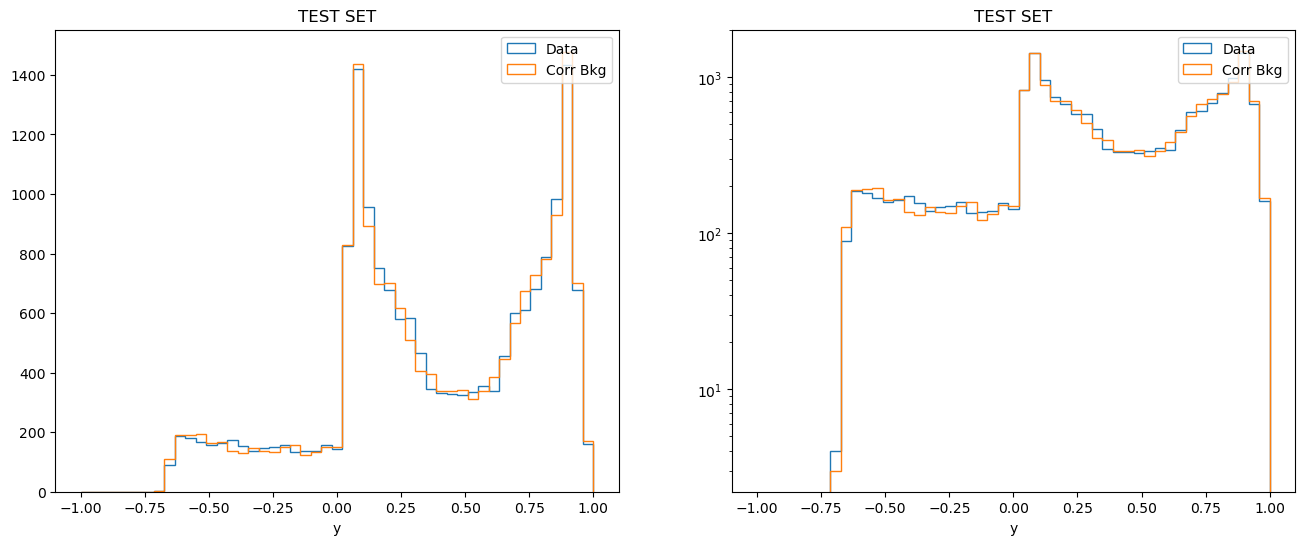

In [70]:
trainer.plotAll([np.linspace(-2,2,50),np.linspace(-1,1,50)])

In [71]:
bkg,l1 = datasets.make_moons(100000,noise=0.02)

data,l2 = datasets.make_moons(100000,noise=0.02)
data[:,0] *= 1.3
data[:,1] *= 0.75
theta = 30*np.pi/180
rot = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])
data = rot.dot(data.T).T

data,bkg_corr,variables = trainer.correctFull(data,bkg)
d = np.concatenate([data[v] for v in variables],axis=1)
b = np.concatenate([bkg_corr[v] for v in variables],axis=1)

100%|██████████| 11/11 [00:00<00:00, 90.79it/s]


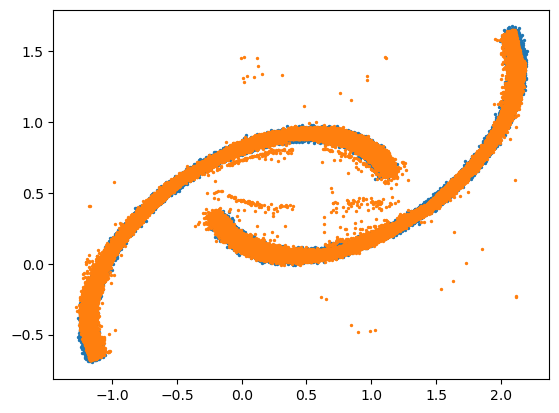

In [72]:
plt.scatter(d[:,0],d[:,1],s=2)
plt.scatter(b[:,0],b[:,1],s=2)

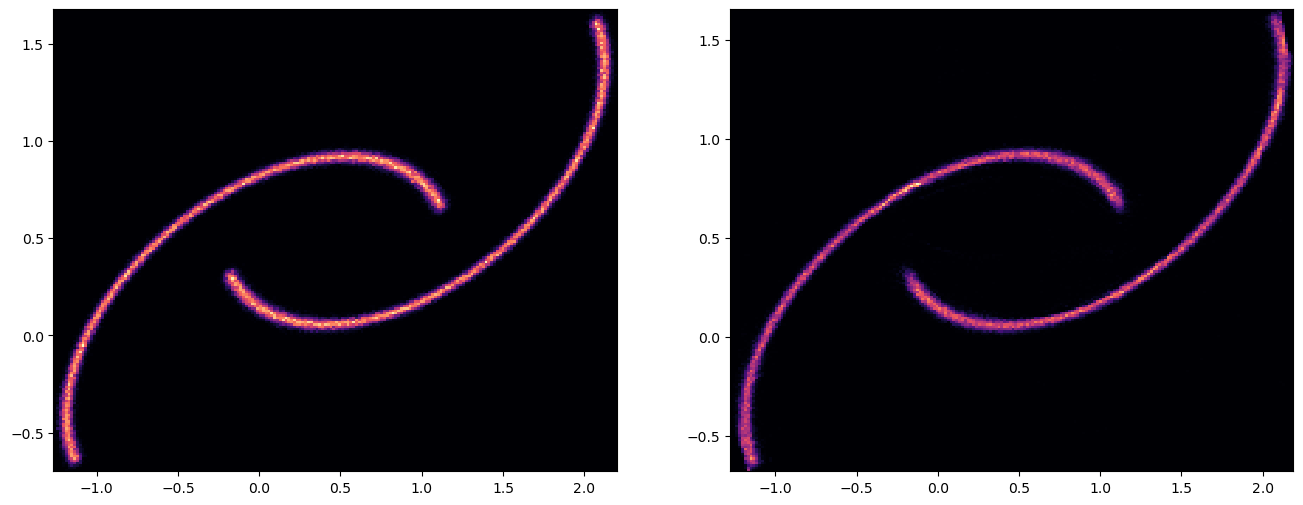

In [73]:
plt.figure(figsize=(16,6))
plt.subplot(121)
h=plt.hist2d(d[:,0],d[:,1],cmap='magma',bins=200,density=True,rasterized=False)
plt.subplot(122)
h=plt.hist2d(b[:,0],b[:,1],cmap='magma',bins=200,density=True,rasterized=False)

# data/mc

In [50]:
#controlVars = ['signed_dEta',"jet1_npf"]
#fitVars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb']
#variables = ['signed_dEta','jet1_npf','jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb']
#variables = ['jet1_rho','jet1_tau21','jet1_tau32']
#variables = ['jet1_rho']
variables = ['jet1_npf','jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb']
btrain = hf.loadData("BKG",variables,nMax=100000,mode='train',dEta_cut=-1,sideband=True)
btest = hf.loadData("BKG",variables,nMax=100000,mode='test',dEta_cut=-1,sideband=True)
dtrain = hf.loadData("DATA",variables,nMax=100000,mode='train',dEta_cut=-1,sideband=True)
dtest = hf.loadData("DATA",variables,nMax=100000,mode='test',dEta_cut=-1,sideband=True)

 15%|█▌        | 6/40 [00:19<01:52,  3.31s/it]


In [51]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.2,"hidden_features":128,
             "num_layers":1,"num_bins":40,"num_blocks_per_layer":15,"tails":"linear",
            "dropout":0.0,"residual":True}
rangeScale = 3
trainer = qrnn.chainedNFTrainer(btrain,btest,dtrain,dtest,variables,control=[0],
                                NF_kwargs=NF_kwargs,rangeScale=rangeScale)

/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/torch/optim/adam.py:48: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  super(Adam, self).__init__(params, defaults)


RUNNING TRAININGS
Training flows bkgFlow_step0_jet1_rho, dataFlow_step0_jet1_rho


Bkg: 0.3986, Data: 0.5508, p =2883: 100%|██████████| 5000/5000 [04:37<00:00, 18.03it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general_simultaneous.py:417: RuntimeWarning: divide by zero encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general_simultaneous.py:417: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general_simultaneous.py:453: RuntimeWarning: divide by zero encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general_simultaneous.py:453: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')


CORRECTING BKG


100%|██████████| 11/11 [00:00<00:00, 21.85it/s]


PLOTTING CORRECTIONS


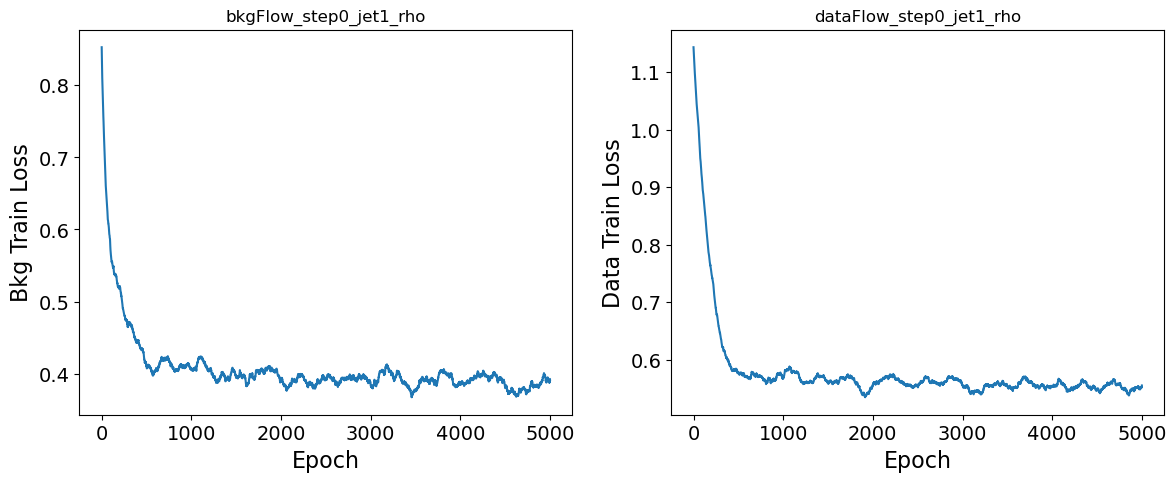

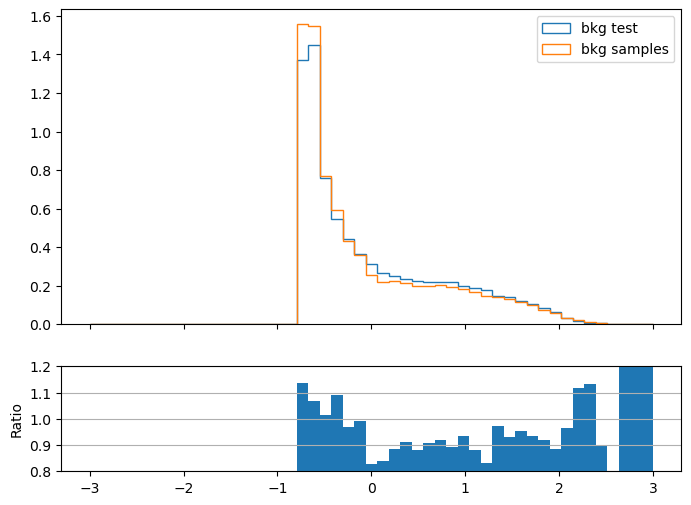

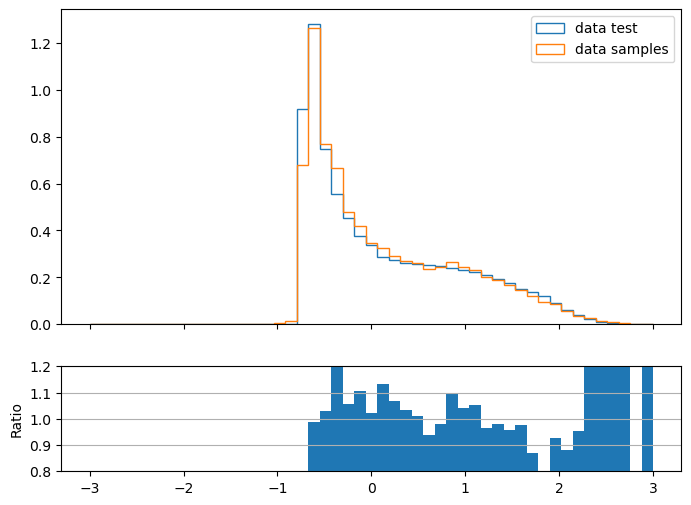

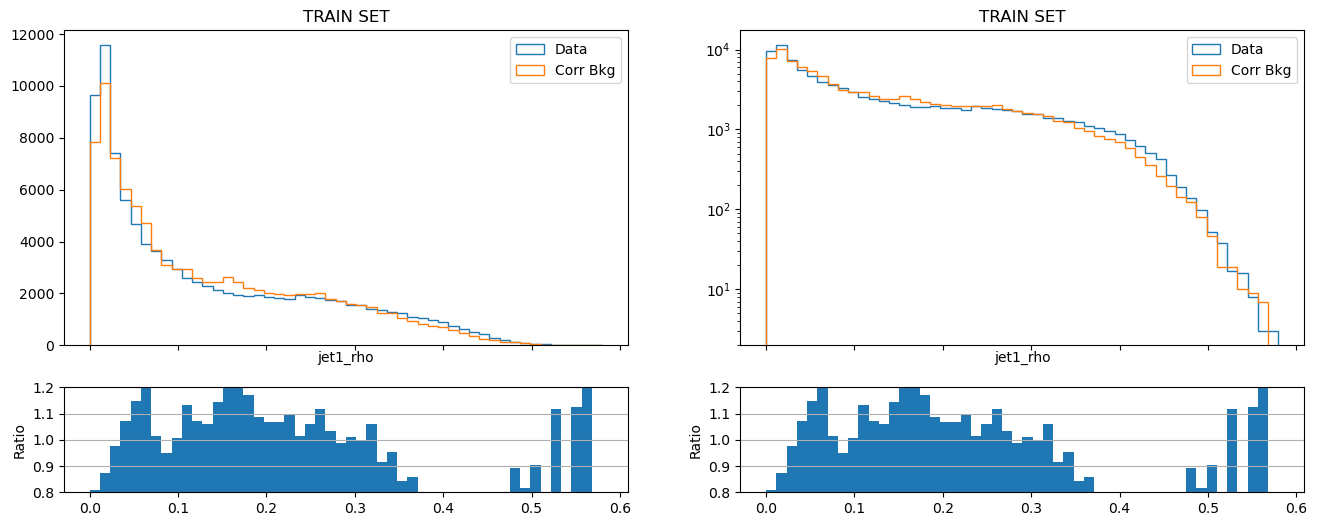

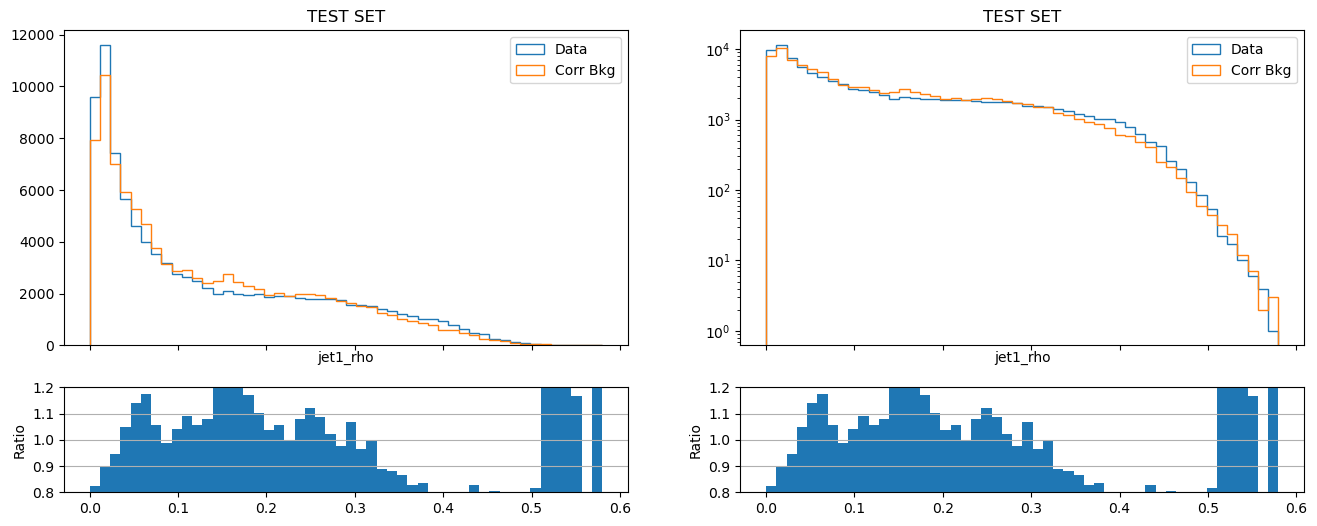

In [52]:
trainer.runCurrent(patience=-1,n_epoch=5000,learning_rate=1e-4,bs=128)

In [13]:
trainer.stepForward()

RUNNING TRAININGS
Training flow bkgFlow_step1_jet1_tau21


Loss: 0.5584281086921692, p = 3028: 100%|██████████| 10000/10000 [03:00<00:00, 55.50it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:364: RuntimeWarning: divide by zero encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:364: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')


Training flow dataFlow_step1_jet1_tau21


Loss: 0.6416692733764648, p = 2616: 100%|██████████| 10000/10000 [02:59<00:00, 55.64it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:389: RuntimeWarning: divide by zero encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')


CORRECTING BKG


100%|██████████| 11/11 [00:00<00:00, 51.83it/s]


PLOTTING CORRECTIONS


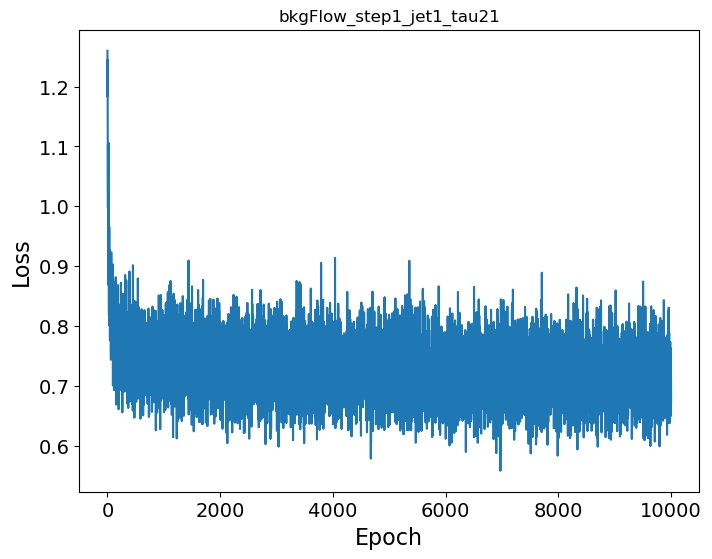

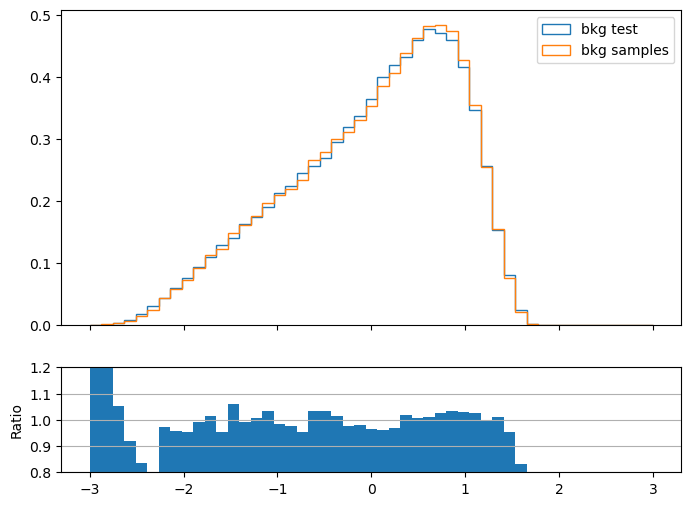

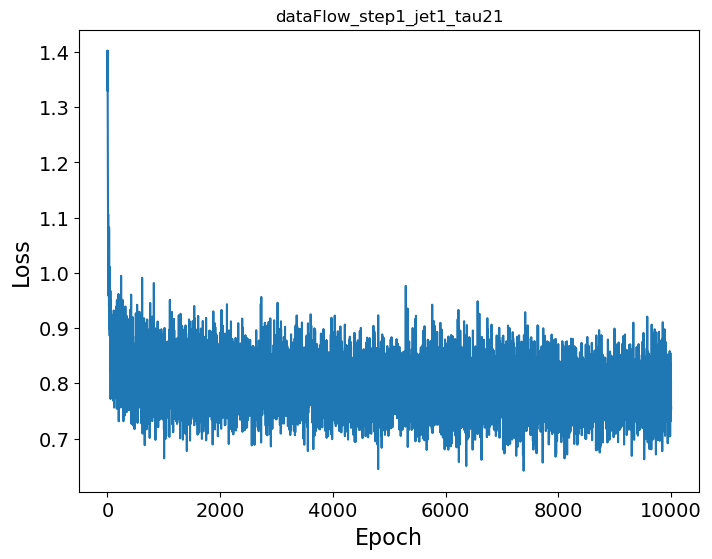

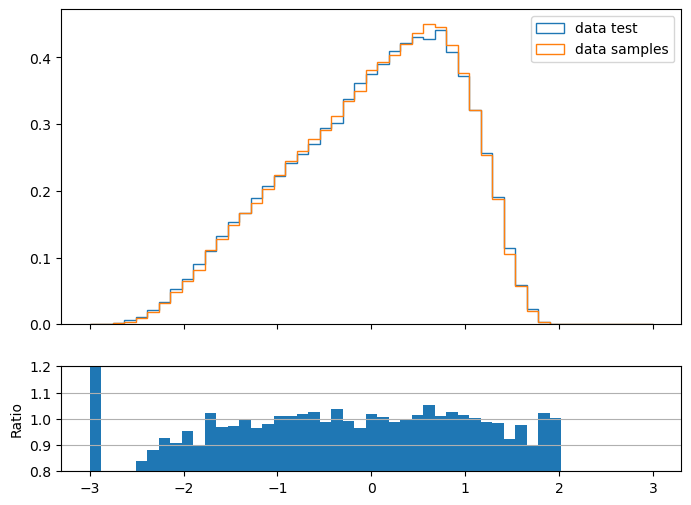

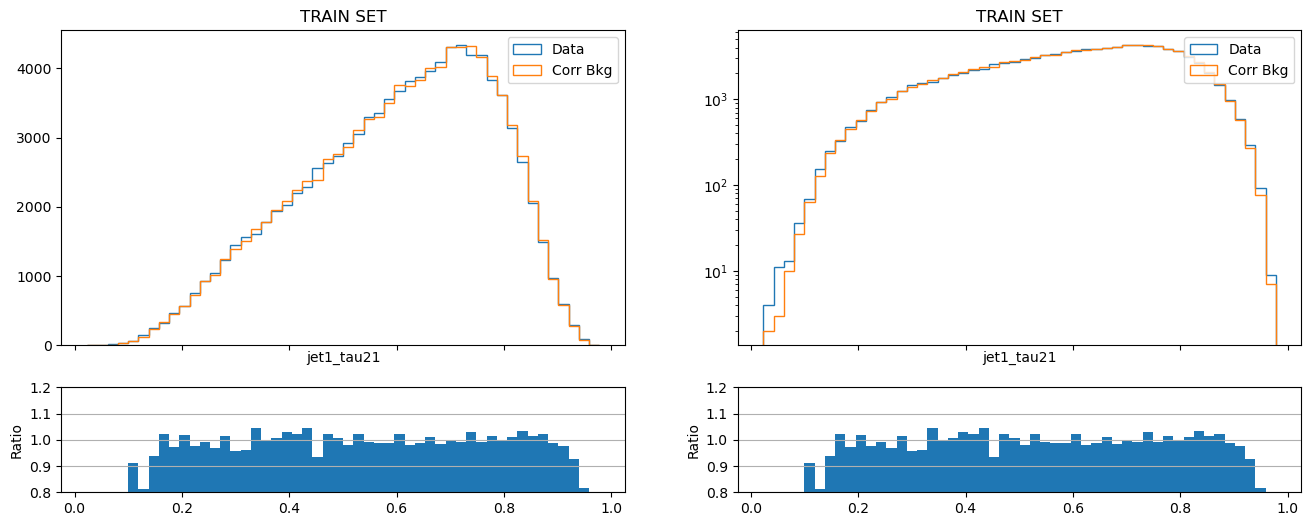

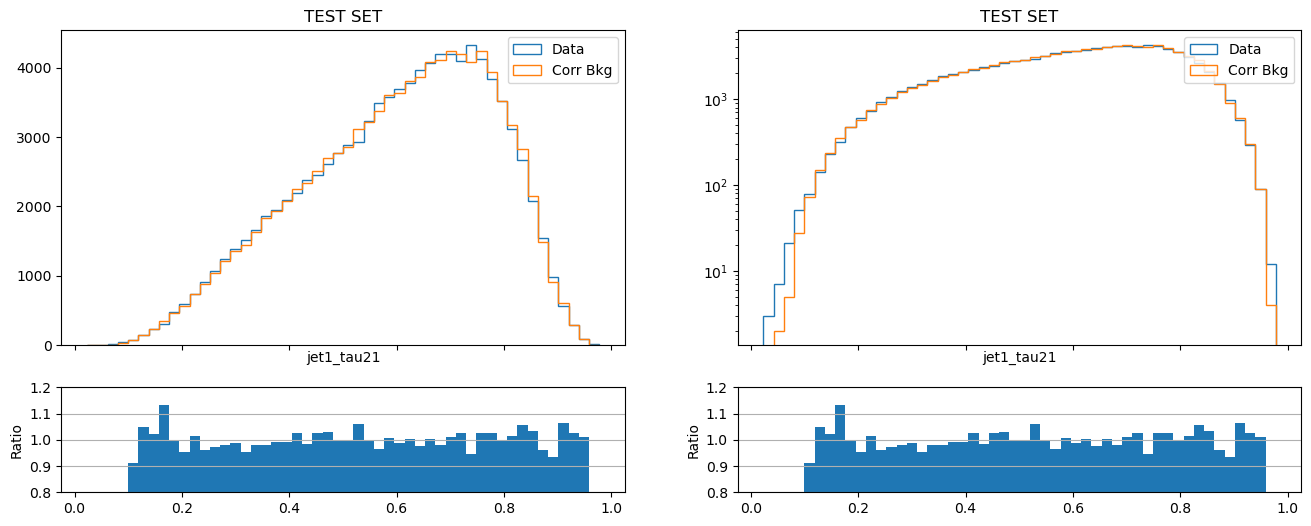

In [14]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.2,"hidden_features":100,
             "num_layers":1,"num_bins":40,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":True}
#trainer.NF_kwargs = NF_kwargs
trainer.runCurrent(patience=-1,n_epoch=10000,learning_rate=1e-3,bs=256)

In [15]:
trainer.stepForward()

RUNNING TRAININGS
Training flow bkgFlow_step3_jet1_tau43


Loss: -0.43325233459472656, p = 6918: 100%|██████████| 10000/10000 [03:00<00:00, 55.28it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:364: RuntimeWarning: divide by zero encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:364: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')


Training flow dataFlow_step3_jet1_tau43


Loss: -0.31915876269340515, p = 371: 100%|██████████| 10000/10000 [03:01<00:00, 55.21it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:389: RuntimeWarning: divide by zero encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:389: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')


CORRECTING BKG


100%|██████████| 11/11 [00:00<00:00, 51.75it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:617: RuntimeWarning: divide by zero encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:617: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:633: RuntimeWarning: divide by zero encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:633: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')


PLOTTING CORRECTIONS


/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:651: RuntimeWarning: divide by zero encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:651: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:667: RuntimeWarning: divide by zero encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:667: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(x=c,height=h2/h1,width=w,align='center')


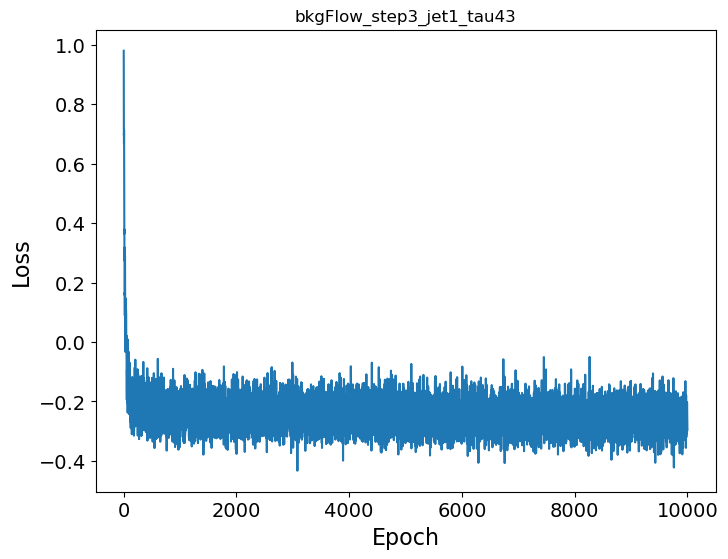

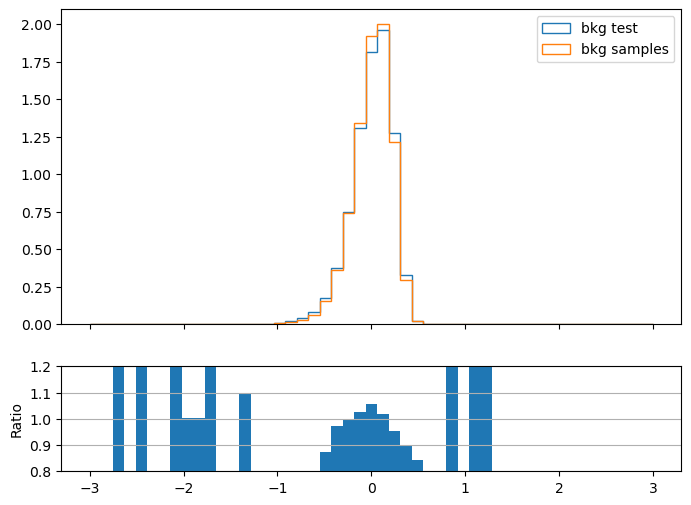

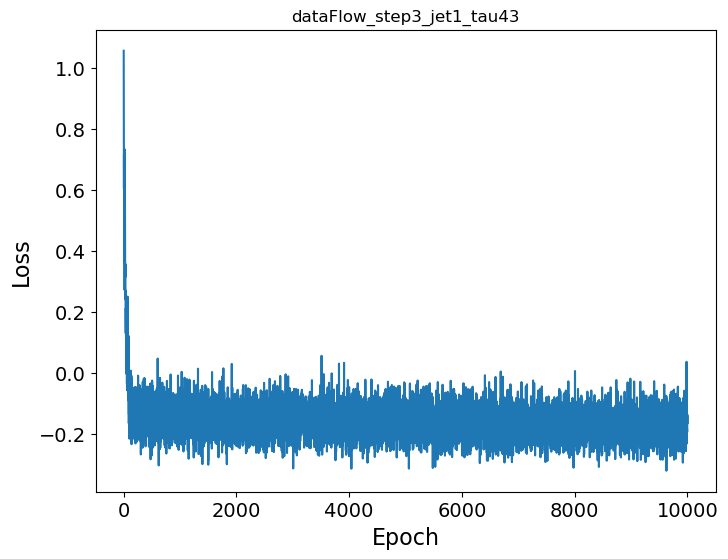

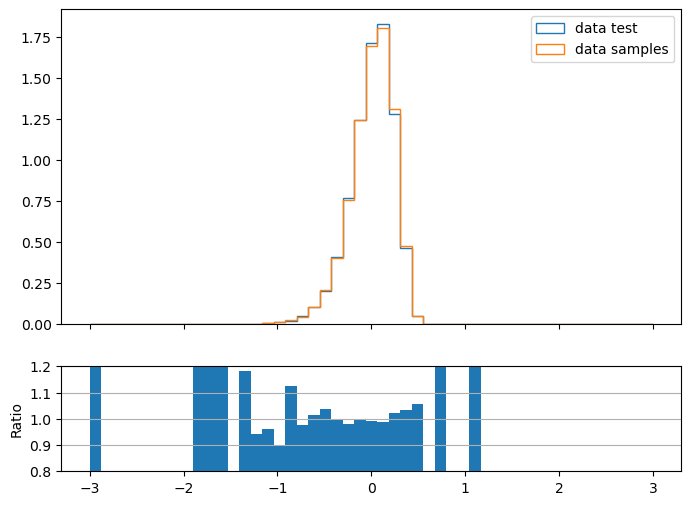

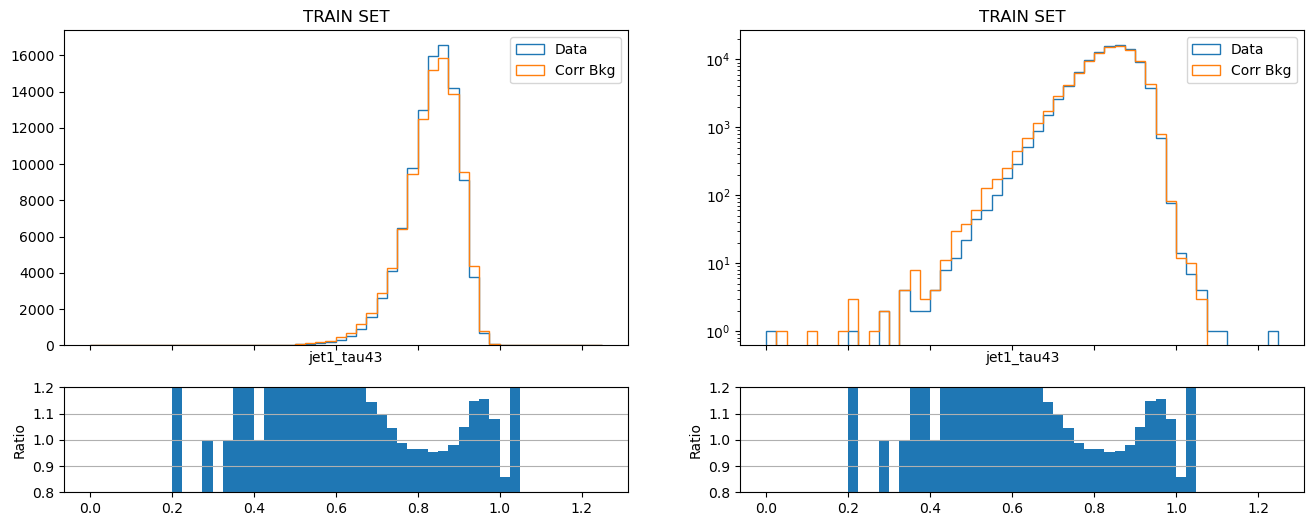

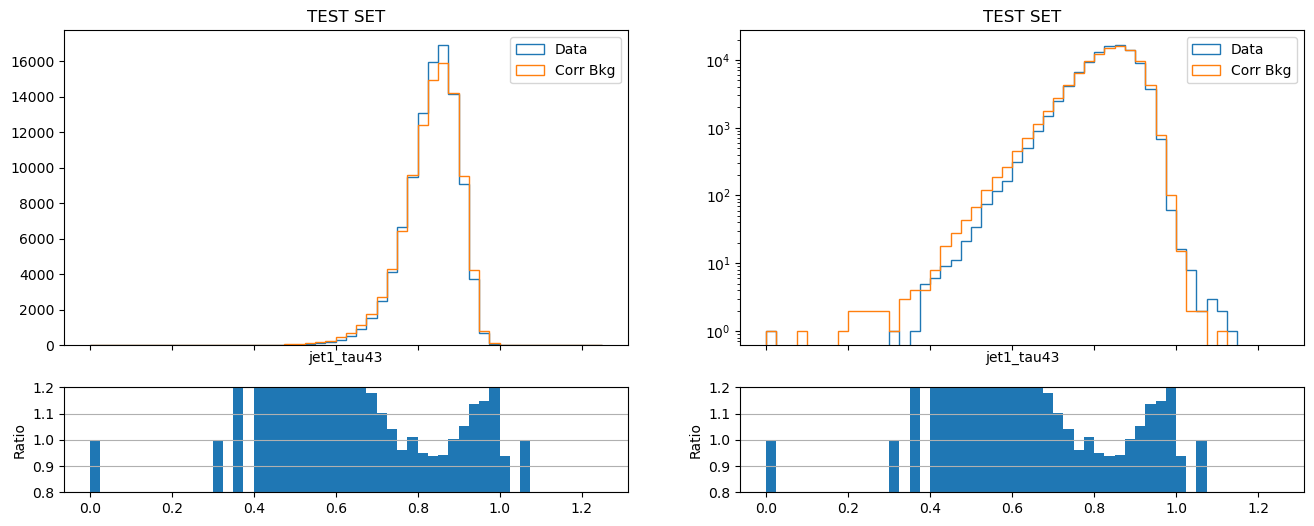

In [20]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.2,"hidden_features":100,
             "num_layers":1,"num_bins":40,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":True}
#trainer.NF_kwargs = NF_kwargs
trainer.runCurrent(patience=-1,n_epoch=10000,learning_rate=1e-3,bs=256)

In [17]:
trainer.stepForward()

RUNNING TRAININGS
Training flow bkgFlow_step3_jet1_tau43


Loss: -0.4776431918144226, p = 856: 100%|██████████| 10000/10000 [02:45<00:00, 60.44it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:367: RuntimeWarning: divide by zero encountered in true_divide
  plt.grid(axis='y')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:367: RuntimeWarning: invalid value encountered in true_divide
  plt.grid(axis='y')


Training flow dataFlow_step3_jet1_tau43


Loss: -0.36699390411376953, p = 1920: 100%|██████████| 10000/10000 [02:46<00:00, 60.16it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:392: RuntimeWarning: divide by zero encountered in true_divide
  plt.grid(axis='y')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:392: RuntimeWarning: invalid value encountered in true_divide
  plt.grid(axis='y')


CORRECTING BKG


100%|██████████| 11/11 [00:00<00:00, 51.28it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:620: RuntimeWarning: divide by zero encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:620: RuntimeWarning: invalid value encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:636: RuntimeWarning: divide by zero encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:636: RuntimeWarning: invalid value encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))


PLOTTING CORRECTIONS


/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:654: RuntimeWarning: divide by zero encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:654: RuntimeWarning: invalid value encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:670: RuntimeWarning: divide by zero encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:670: RuntimeWarning: invalid value encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))


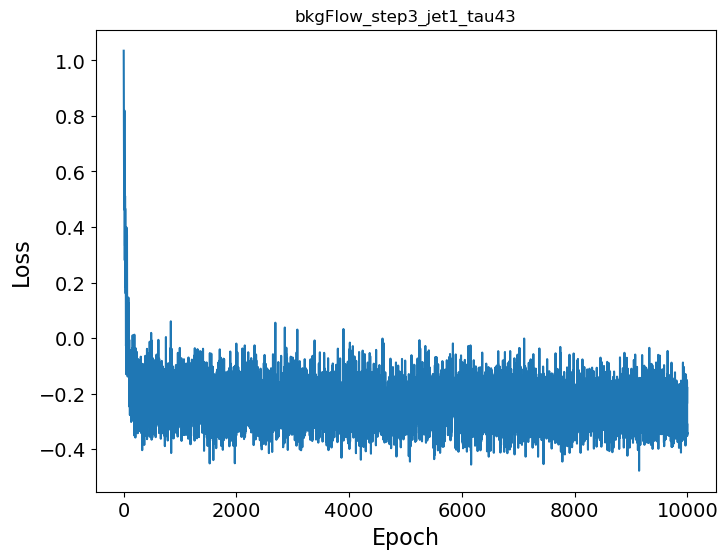

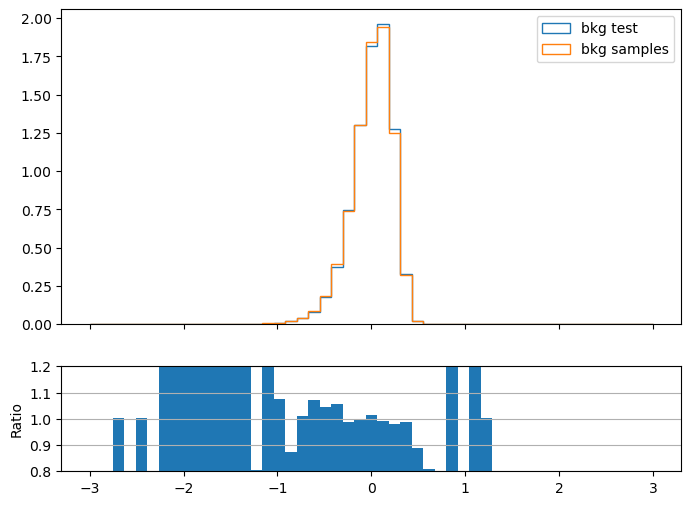

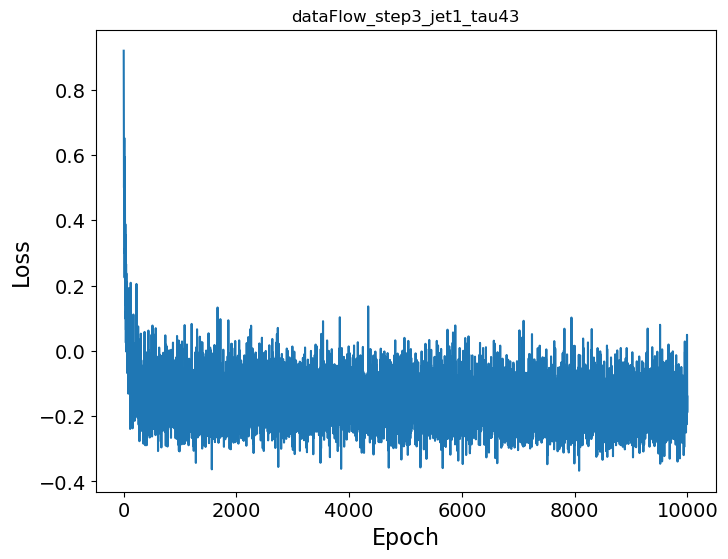

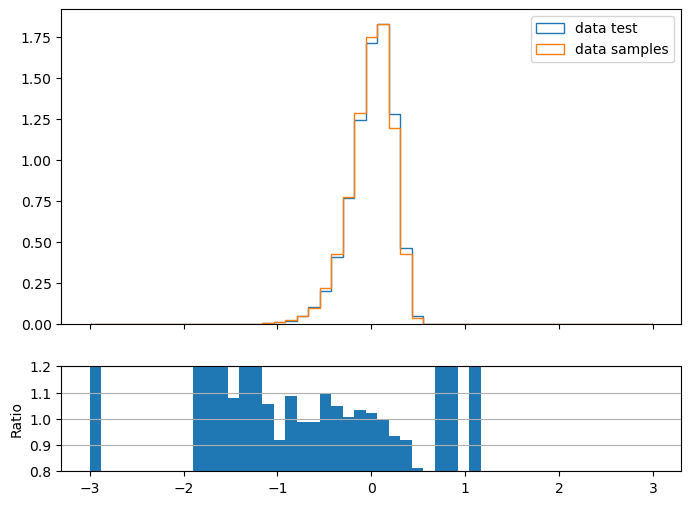

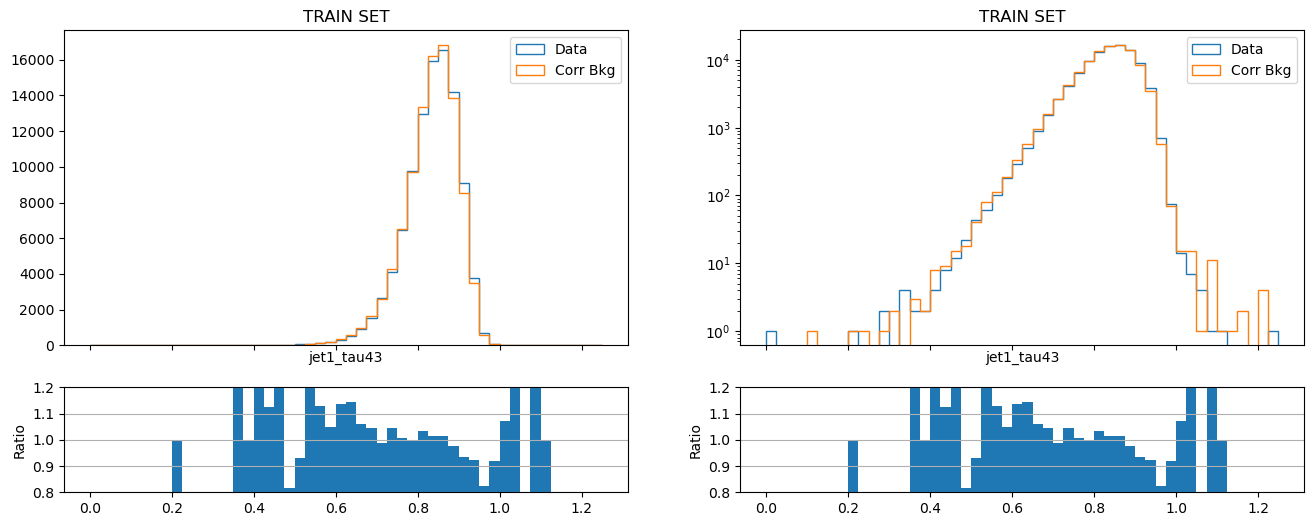

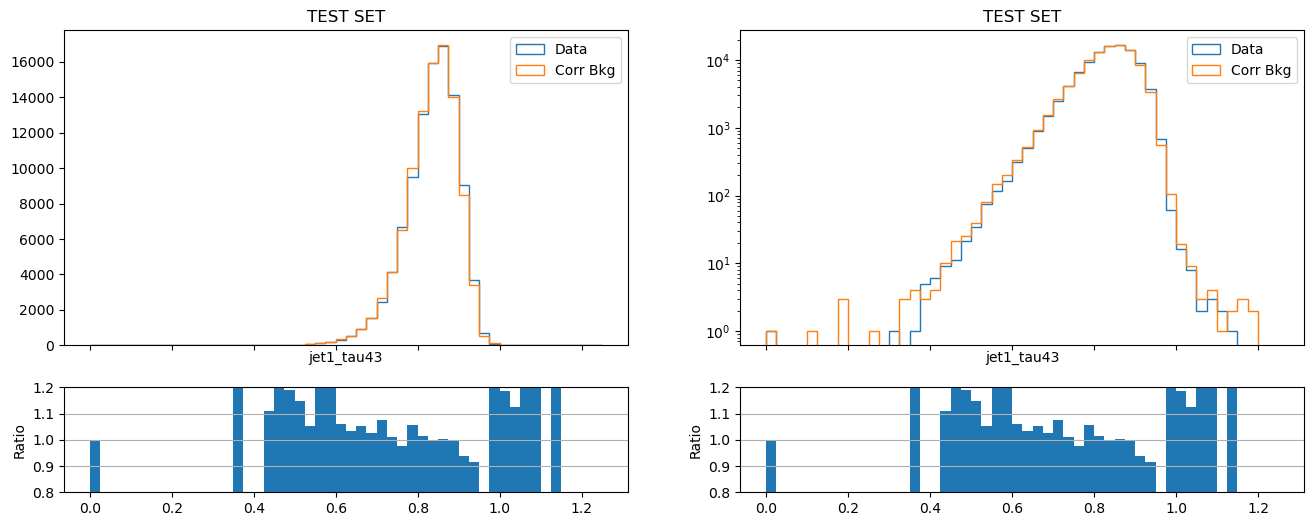

In [23]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.2,"hidden_features":128,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":15,"tails":"linear",
            "dropout":0.0,"residual":True}
#trainer.NF_kwargs = NF_kwargs
trainer.runCurrent(patience=-1,n_epoch=10000,learning_rate=1e-3,bs=128,wd=1e-4)

In [24]:
trainer.stepForward()

RUNNING TRAININGS
Training flow bkgFlow_step4_jet1_logTauS


Loss: -0.5855878591537476, p = 3065: 100%|██████████| 10000/10000 [02:46<00:00, 60.16it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:367: RuntimeWarning: divide by zero encountered in true_divide
  plt.grid(axis='y')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:367: RuntimeWarning: invalid value encountered in true_divide
  plt.grid(axis='y')


Training flow dataFlow_step4_jet1_logTauS


Loss: -0.7520226836204529, p = 261: 100%|██████████| 10000/10000 [02:46<00:00, 60.03it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:392: RuntimeWarning: divide by zero encountered in true_divide
  plt.grid(axis='y')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:392: RuntimeWarning: invalid value encountered in true_divide
  plt.grid(axis='y')


CORRECTING BKG


100%|██████████| 11/11 [00:00<00:00, 51.23it/s]


PLOTTING CORRECTIONS


/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:654: RuntimeWarning: divide by zero encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:670: RuntimeWarning: divide by zero encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))


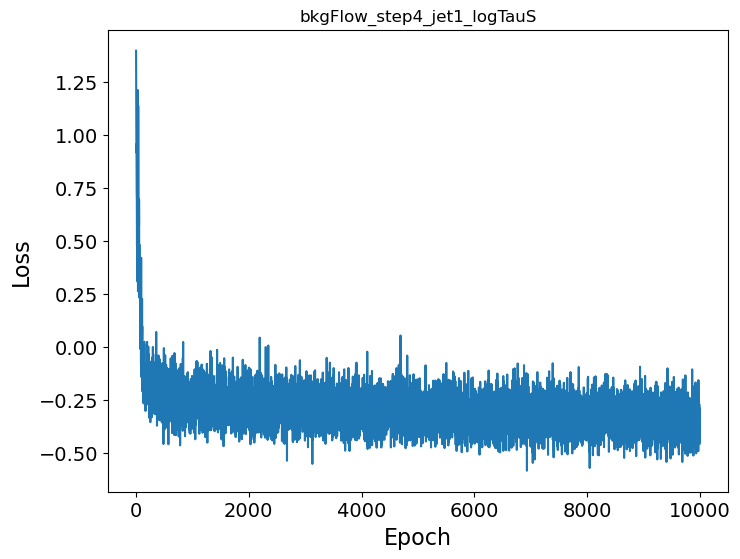

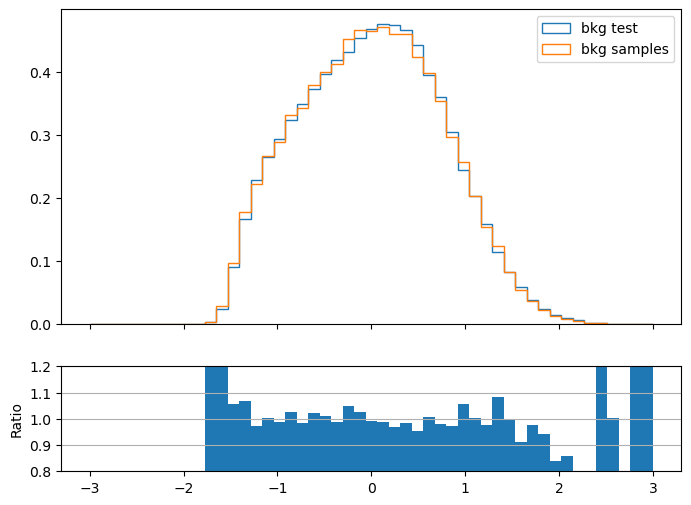

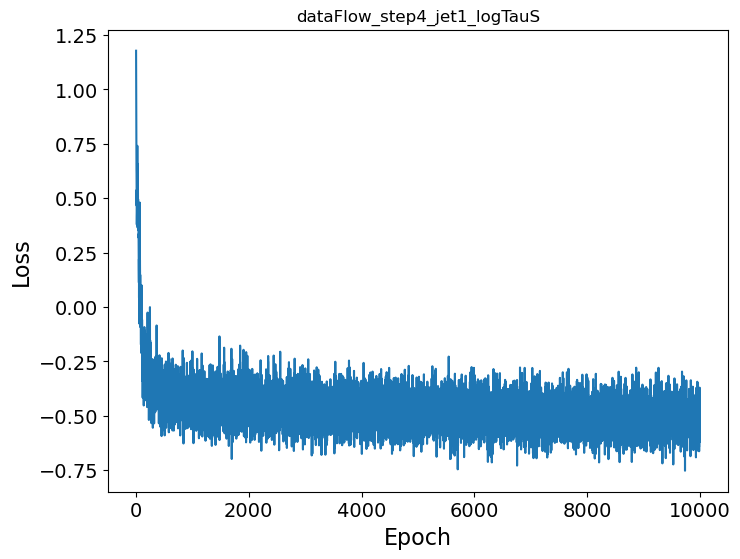

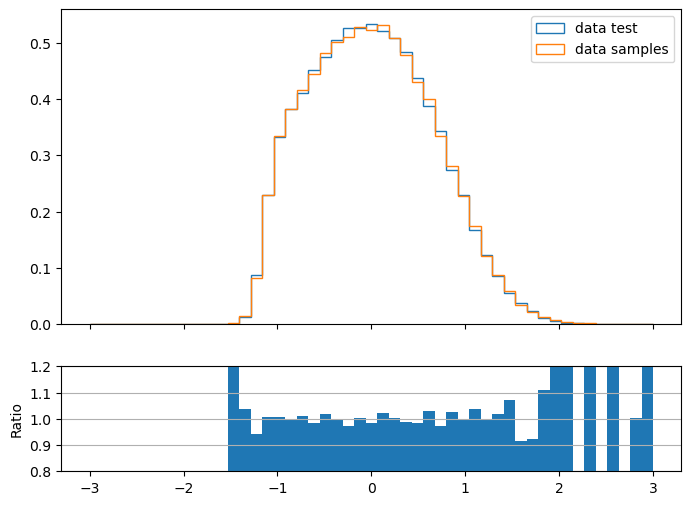

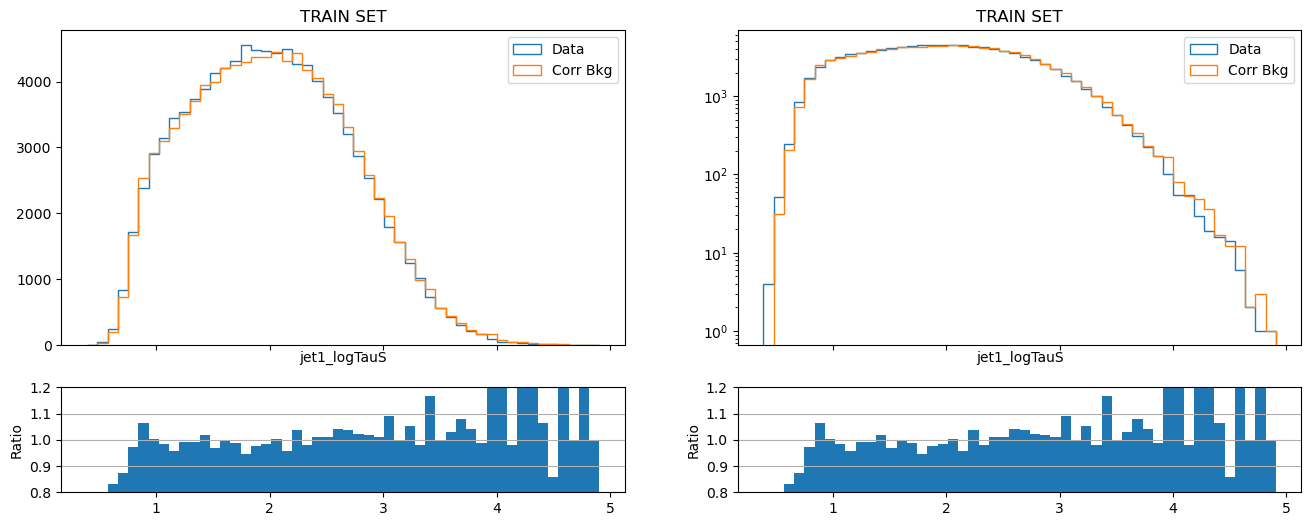

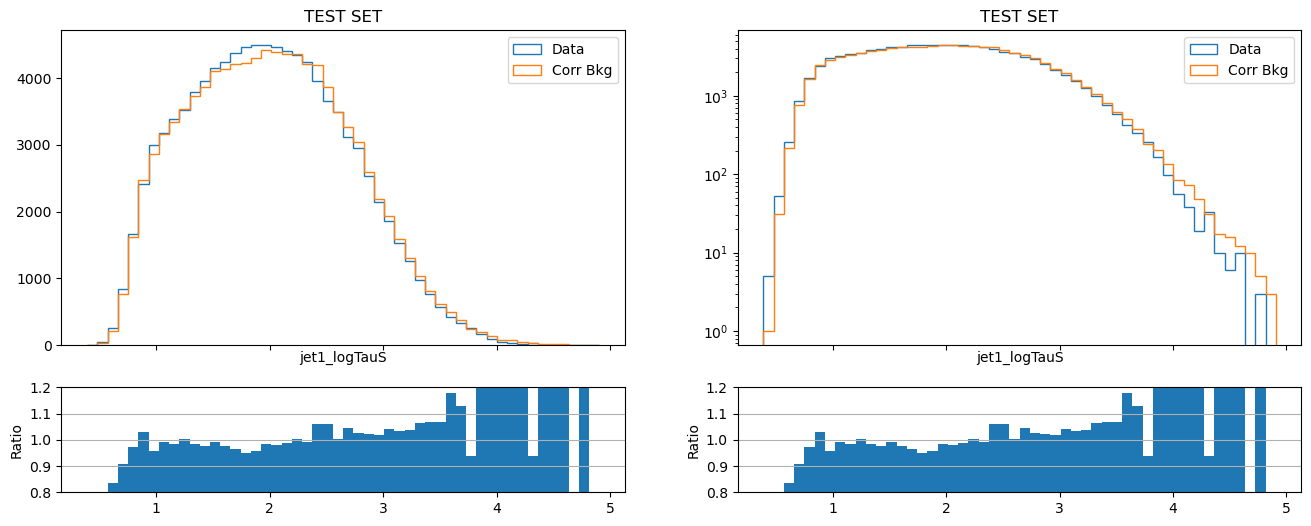

In [25]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.2,"hidden_features":128,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":15,"tails":"linear",
            "dropout":0.0,"residual":True}
#trainer.NF_kwargs = NF_kwargs
trainer.runCurrent(patience=-1,n_epoch=10000,learning_rate=1e-3,bs=128,wd=1e-4)

In [26]:
trainer.stepForward()

RUNNING TRAININGS
Training flow bkgFlow_step5_jet1_pb


Loss: -0.08097882568836212, p = 717: 100%|██████████| 10000/10000 [02:45<00:00, 60.39it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:367: RuntimeWarning: divide by zero encountered in true_divide
  plt.grid(axis='y')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:367: RuntimeWarning: invalid value encountered in true_divide
  plt.grid(axis='y')


Training flow dataFlow_step5_jet1_pb


Loss: 0.13949541747570038, p = 1624: 100%|██████████| 10000/10000 [02:46<00:00, 60.19it/s]
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:392: RuntimeWarning: divide by zero encountered in true_divide
  plt.grid(axis='y')
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:392: RuntimeWarning: invalid value encountered in true_divide
  plt.grid(axis='y')


CORRECTING BKG


100%|██████████| 11/11 [00:00<00:00, 50.86it/s]


PLOTTING CORRECTIONS


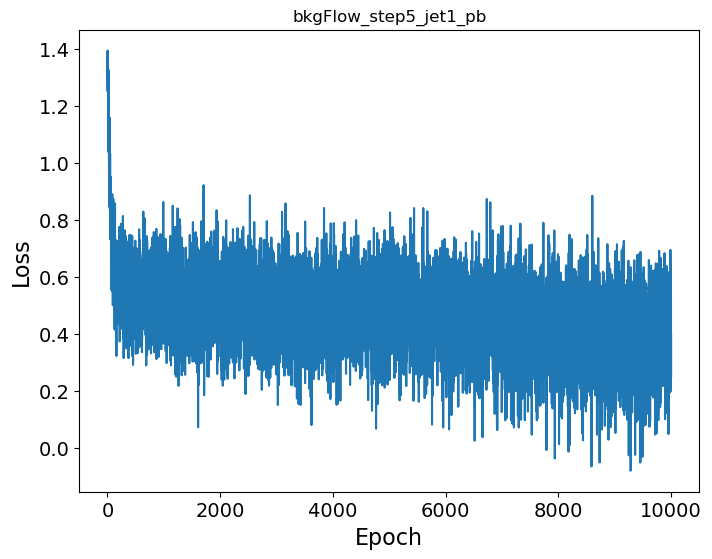

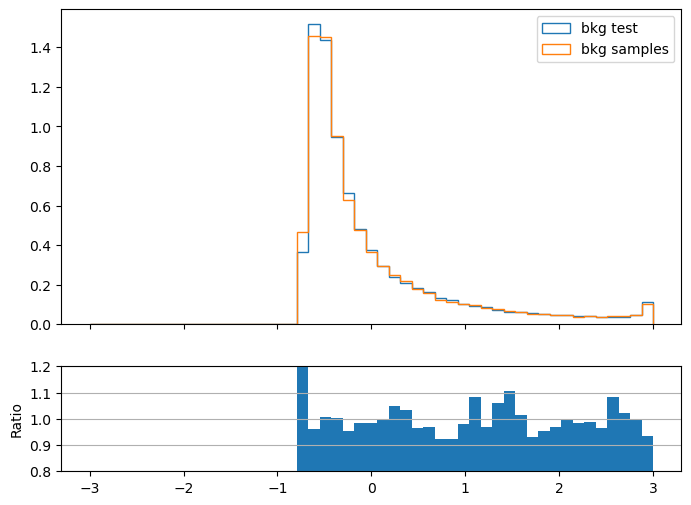

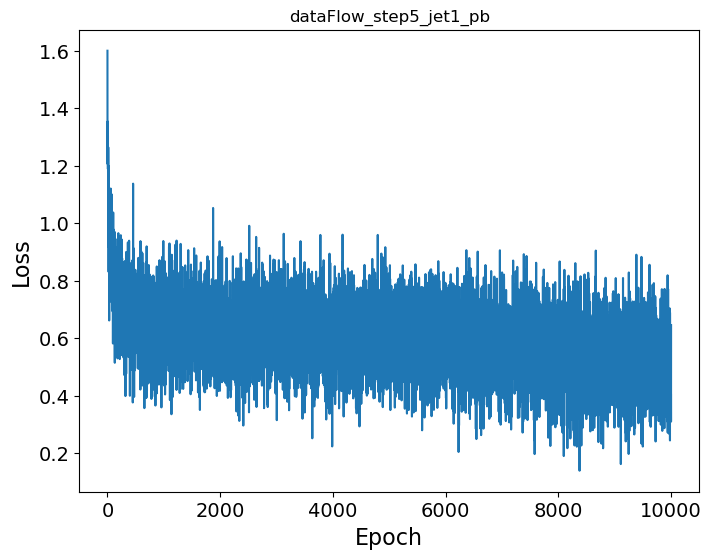

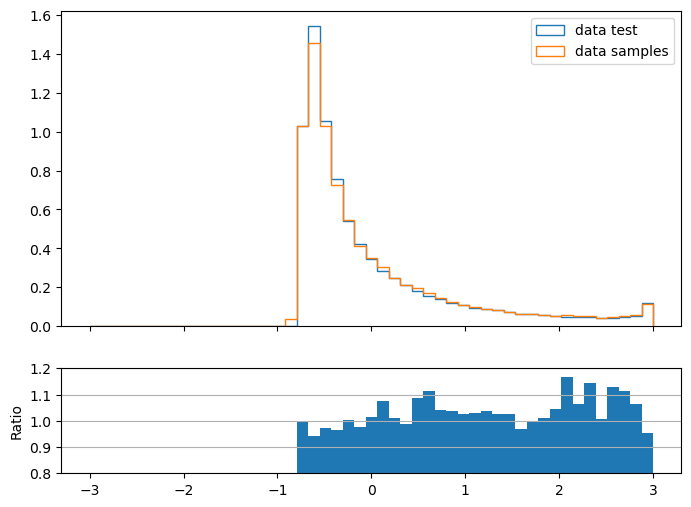

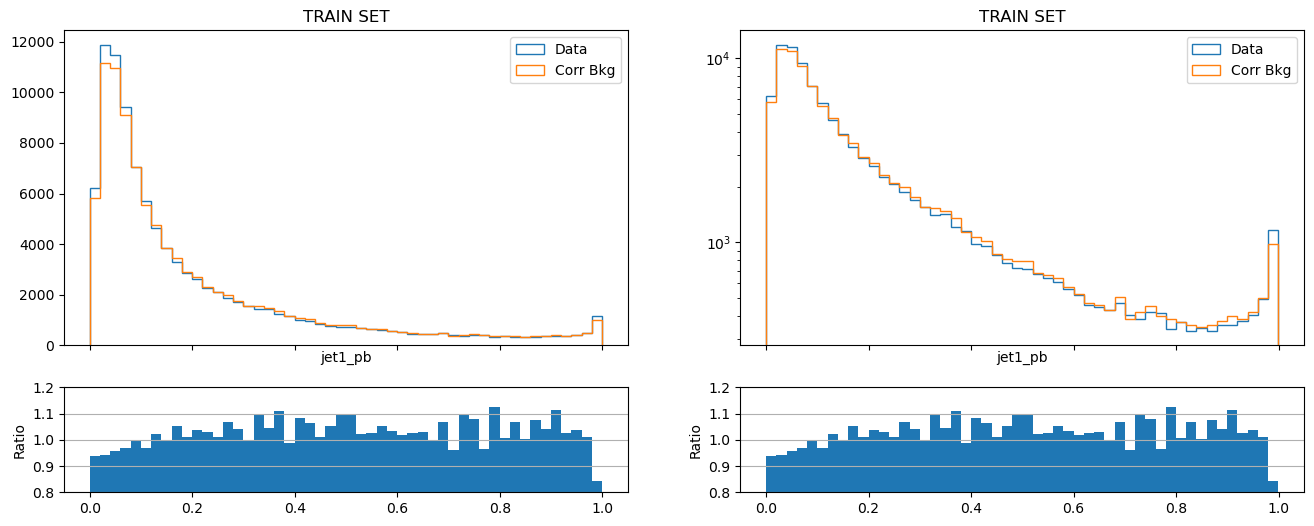

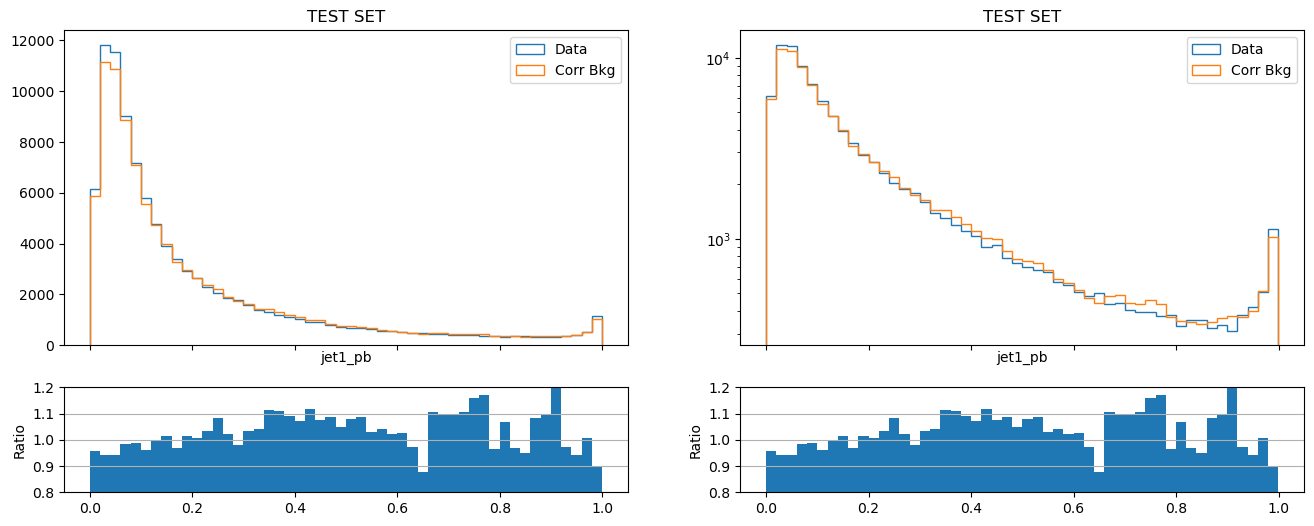

In [27]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.2,"hidden_features":128,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":15,"tails":"linear",
            "dropout":0.0,"residual":True}
#trainer.NF_kwargs = NF_kwargs
trainer.runCurrent(patience=-1,n_epoch=10000,learning_rate=1e-3,bs=128,wd=1e-4)

/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:654: RuntimeWarning: divide by zero encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:654: RuntimeWarning: invalid value encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:670: RuntimeWarning: divide by zero encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:670: RuntimeWarning: invalid value encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:620: RuntimeWarning: invalid value encountered in true_divide
  plt.yticks(np.arange(0.8,1.3,0.1))
/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs_general.py:636: RuntimeWarning: invalid value encountered in true_divide
  p

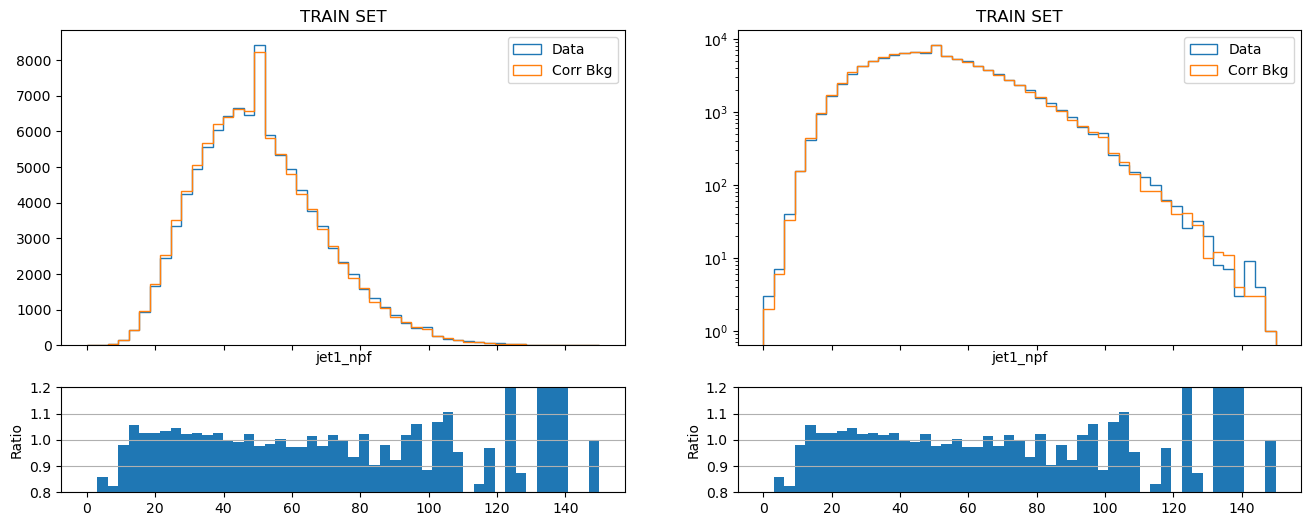

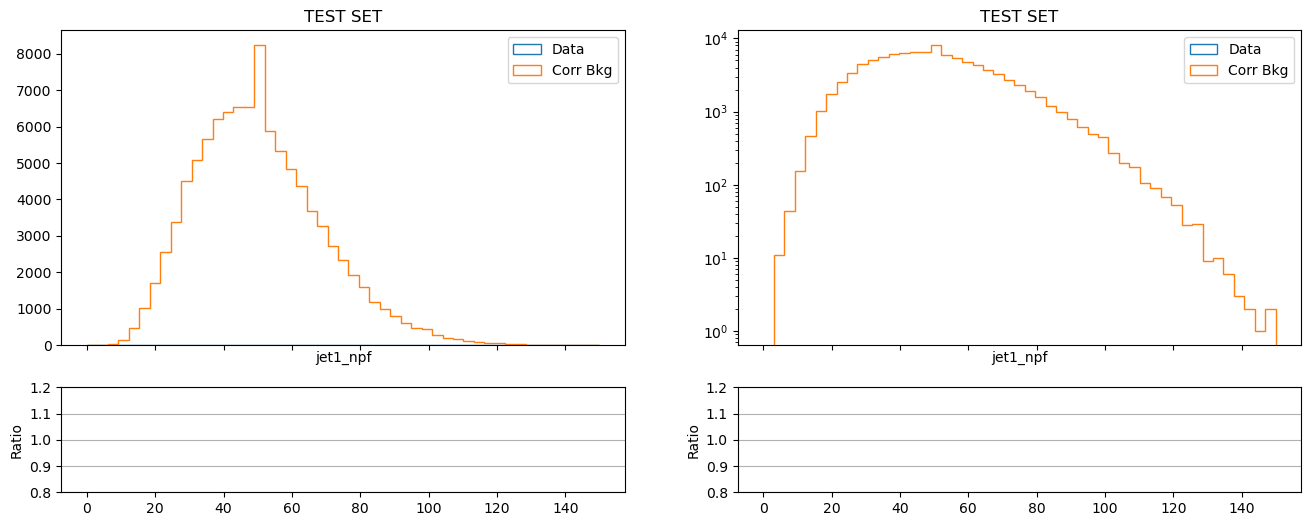

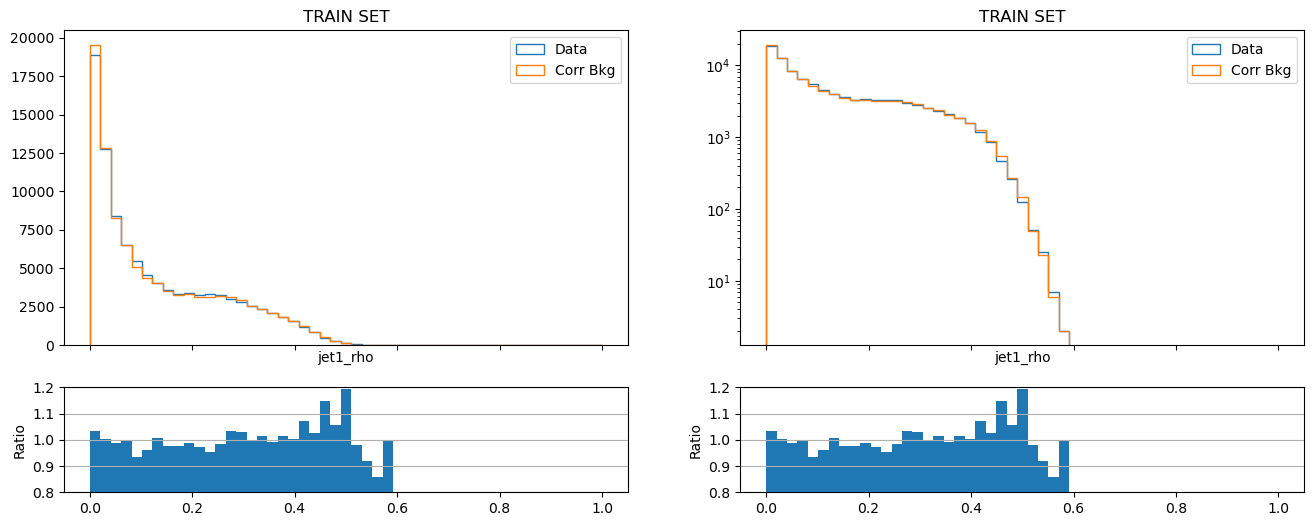

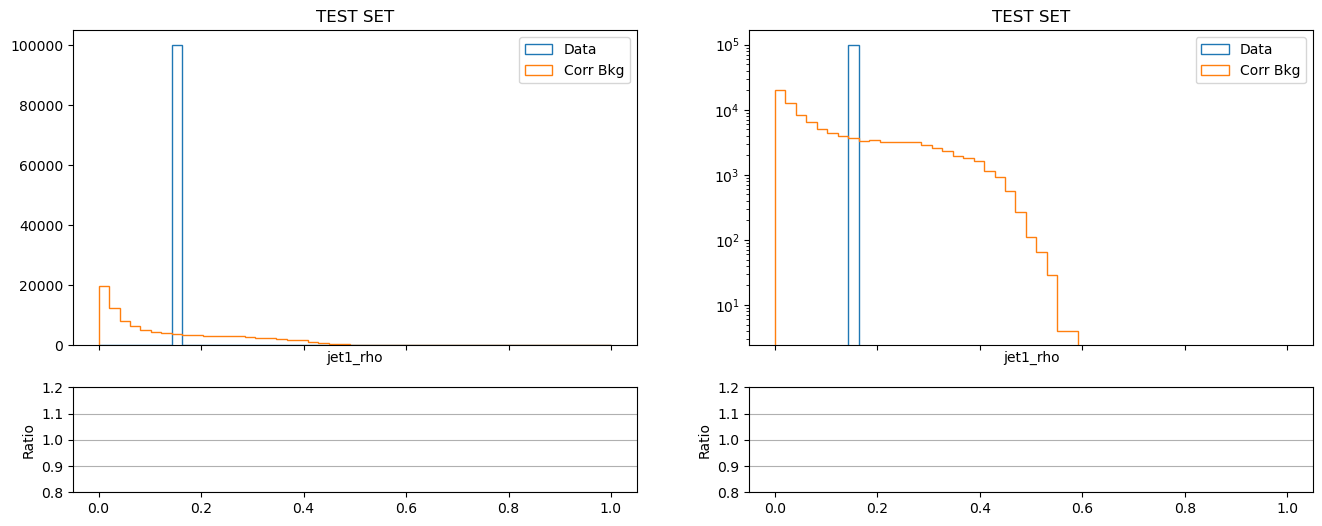

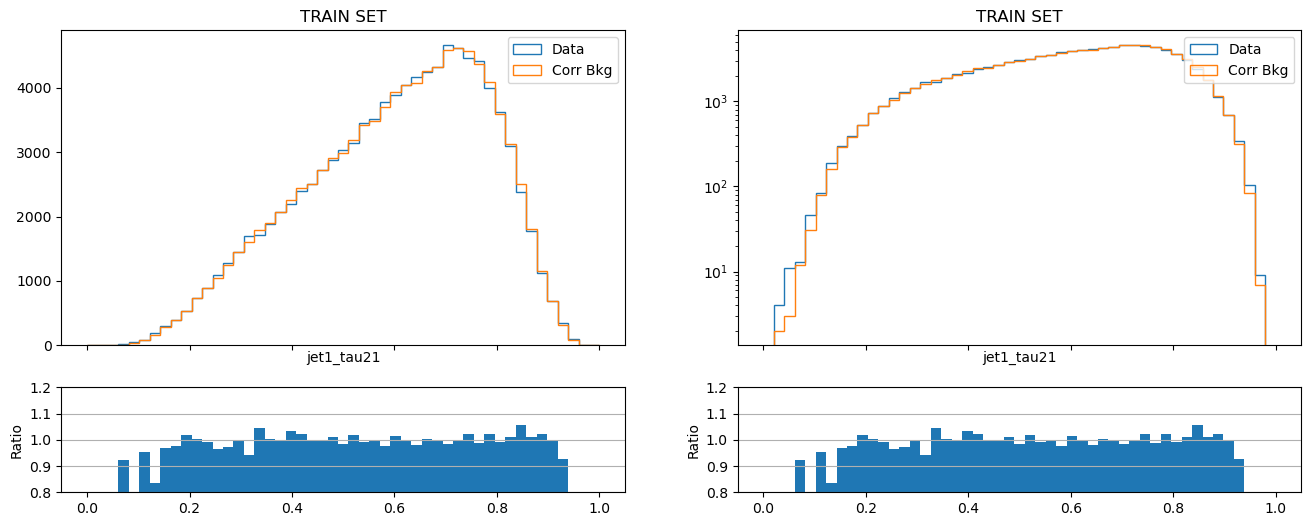

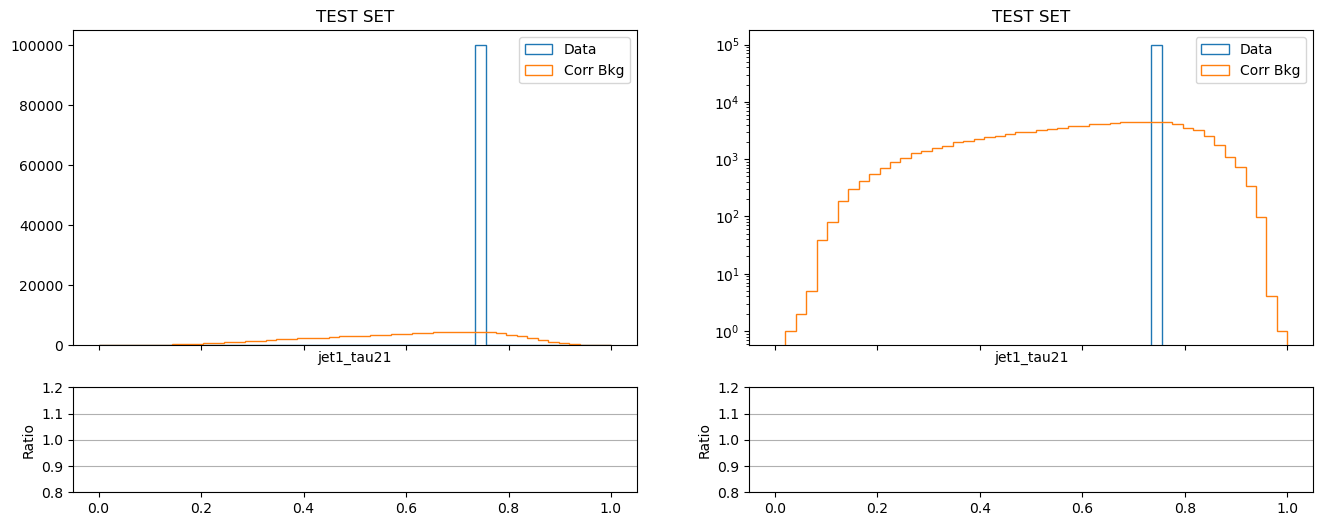

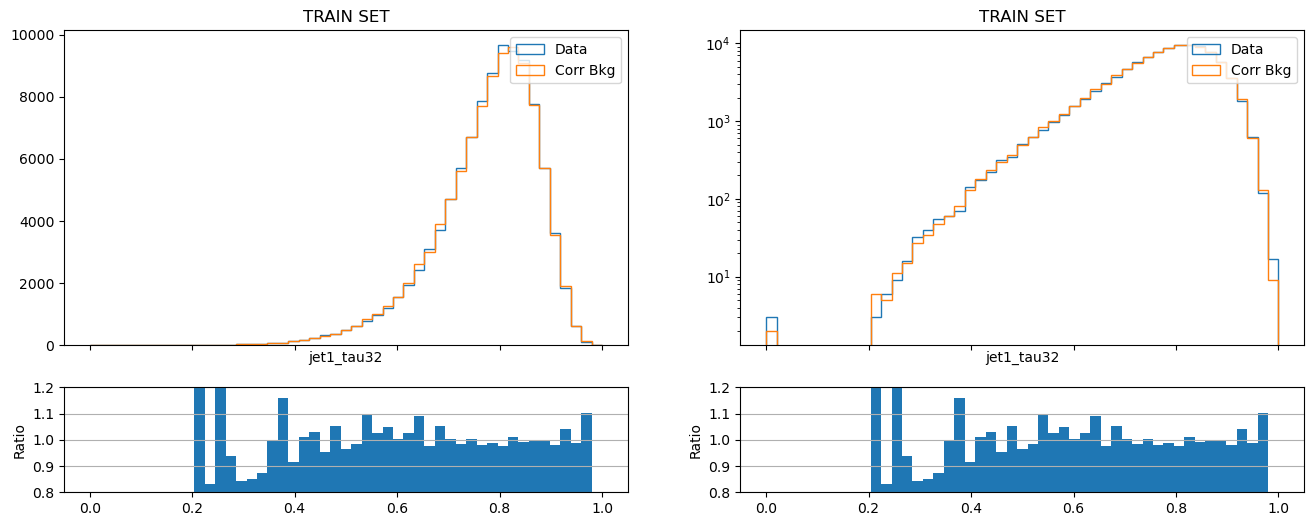

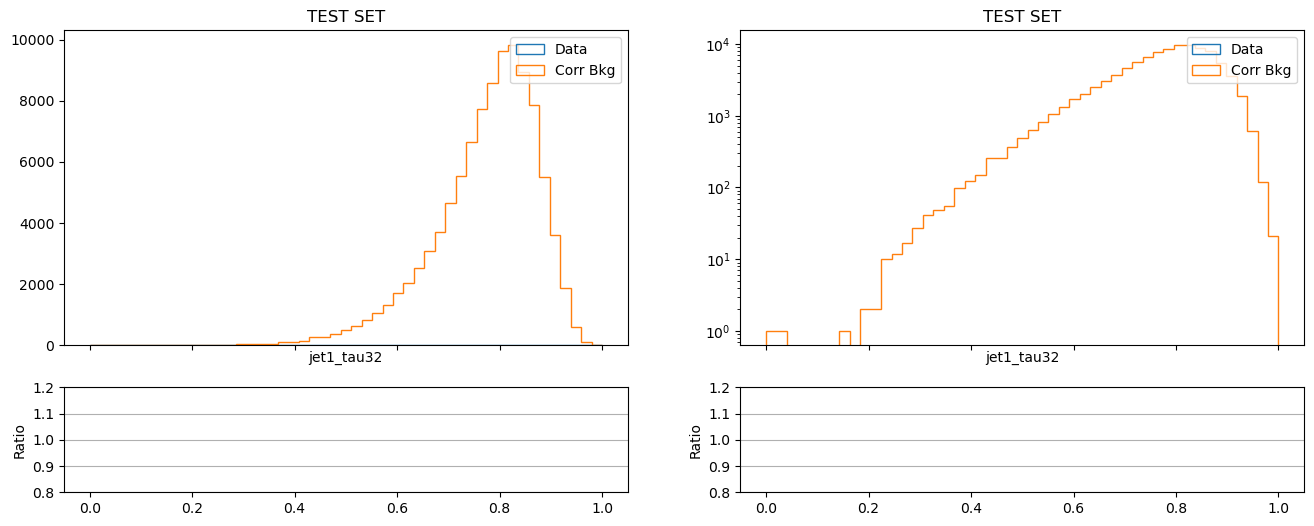

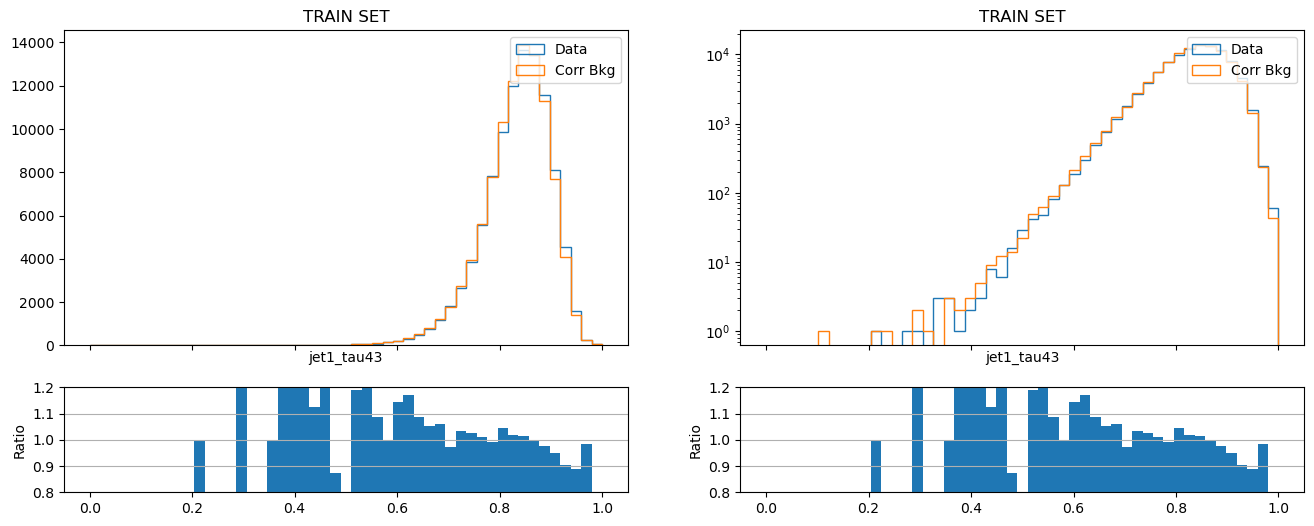

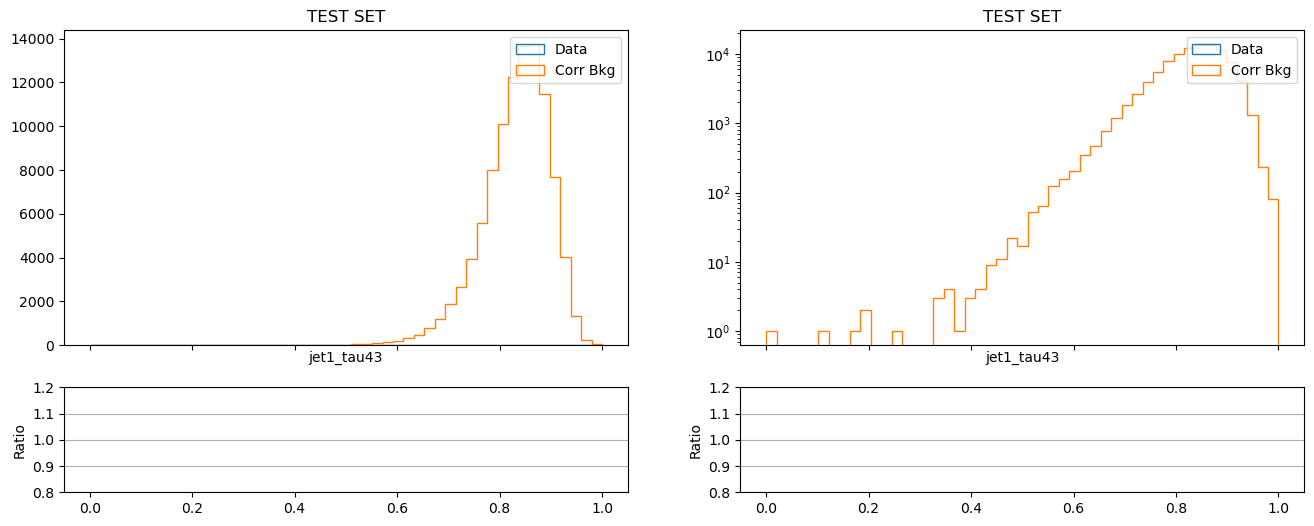

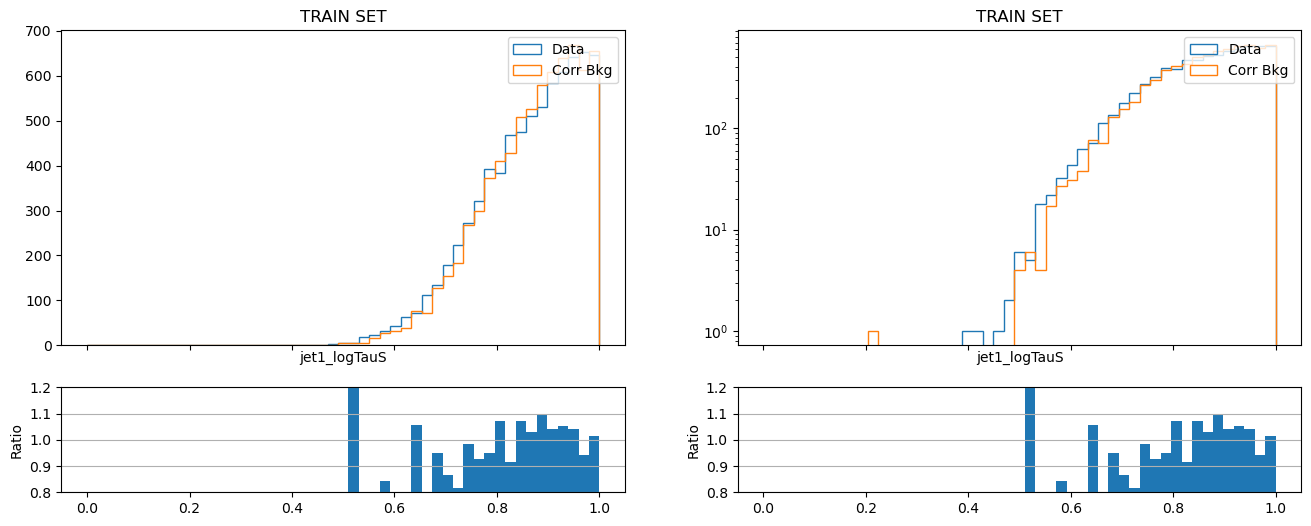

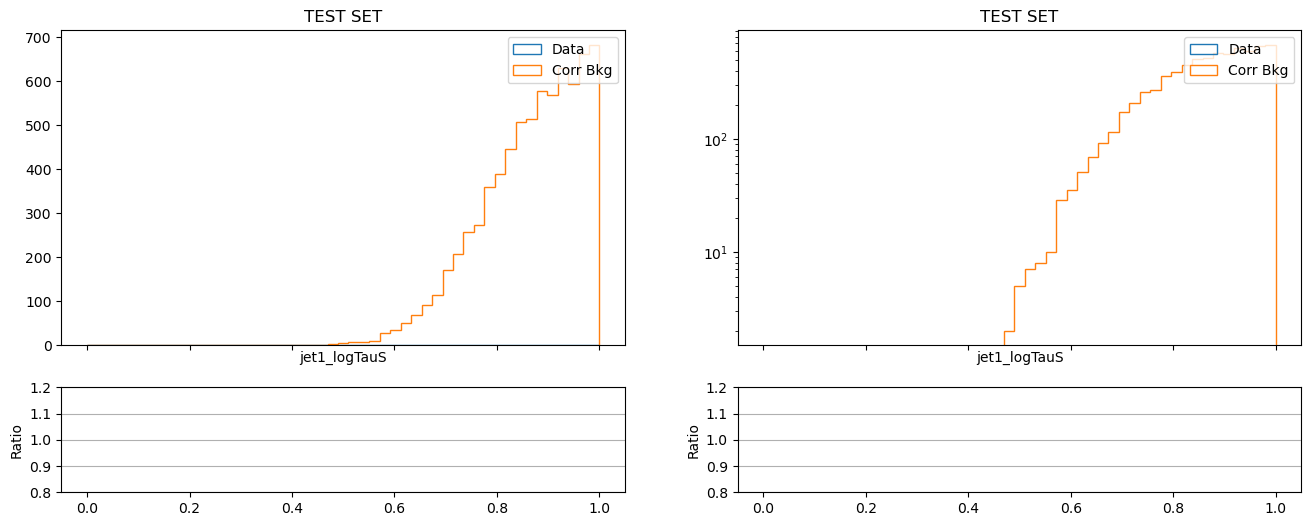

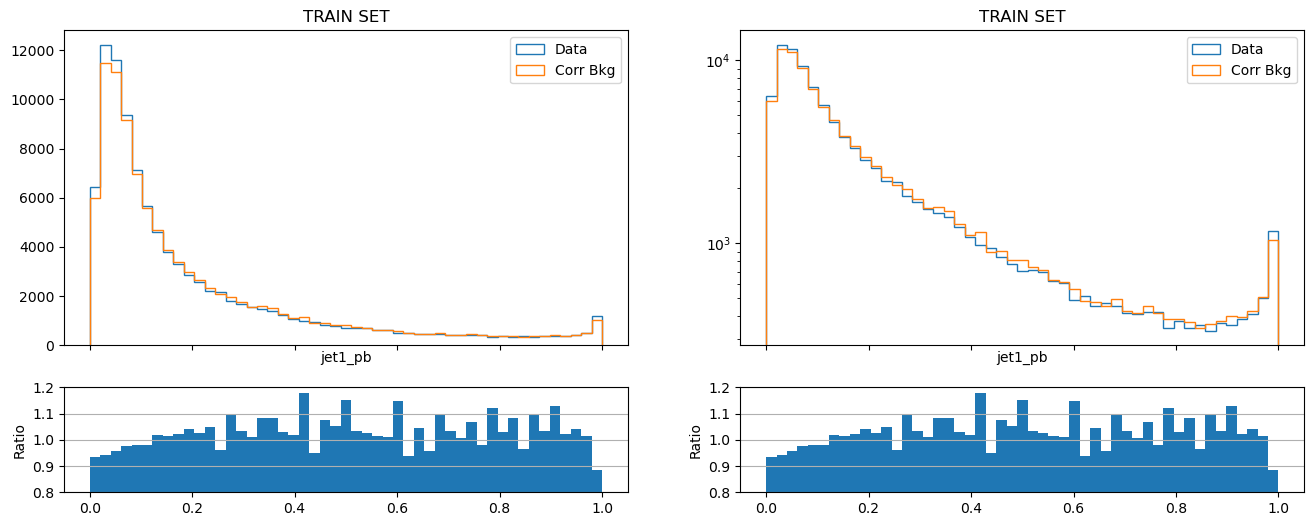

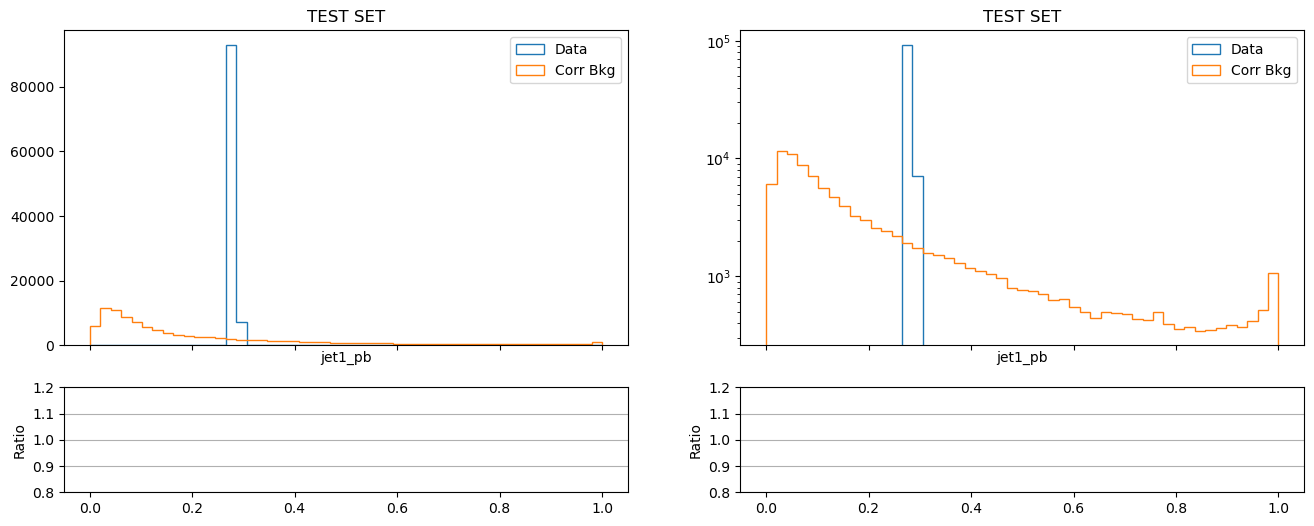

In [41]:
trainer.plotAll([np.linspace(0,150,50)]+7*[np.linspace(0,1,50)])

In [50]:
data = dtest
bkg_old = btest
data,bkg_corr,vnames = trainer.correctFull(data,bkg_old,n_per=10000)
bkg_old = {v:bkg_old[:,i].reshape(-1,1) for i,v in enumerate(variables)}
#bkg_old = trainer.bkg_test
#for v in variables:
#    idx = trainer.varNames.index(v)
#    data[v] = trainer.scale(data[v],"data",forward=False,idx=idx)
    #bkg_old[v] = trainer.scale(bkg_old[v],"bkg",forward=False,idx=idx)

100%|██████████| 11/11 [00:00<00:00, 98.77it/s]


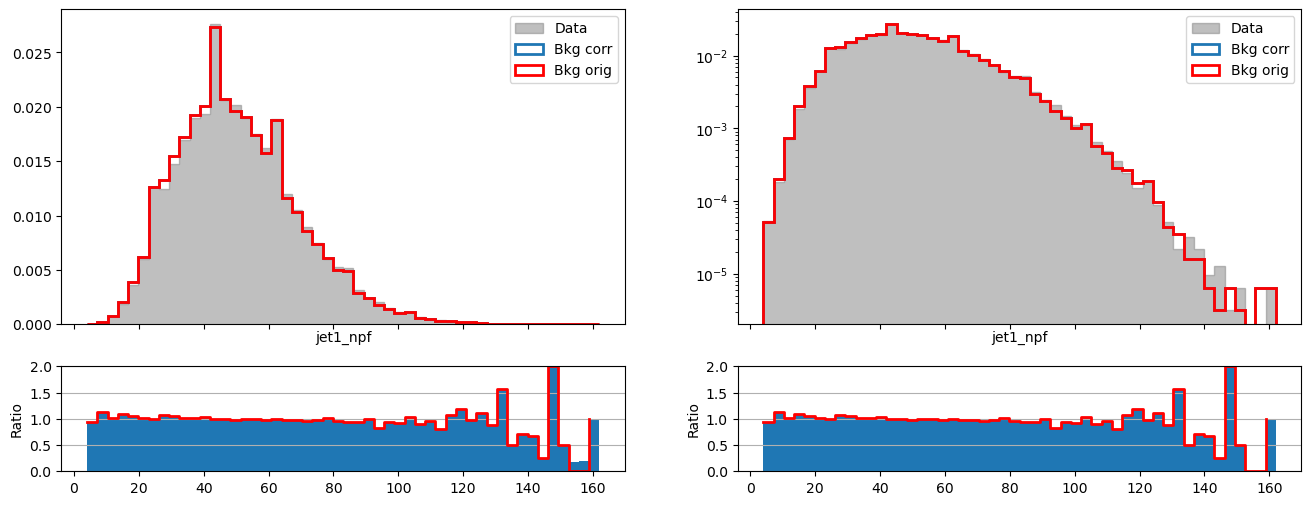

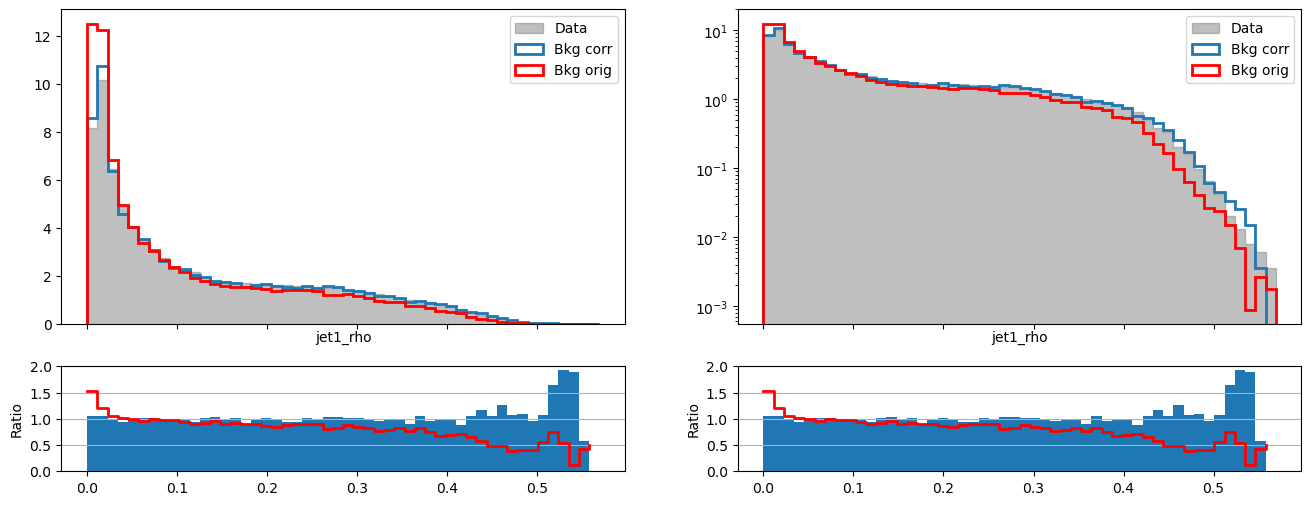

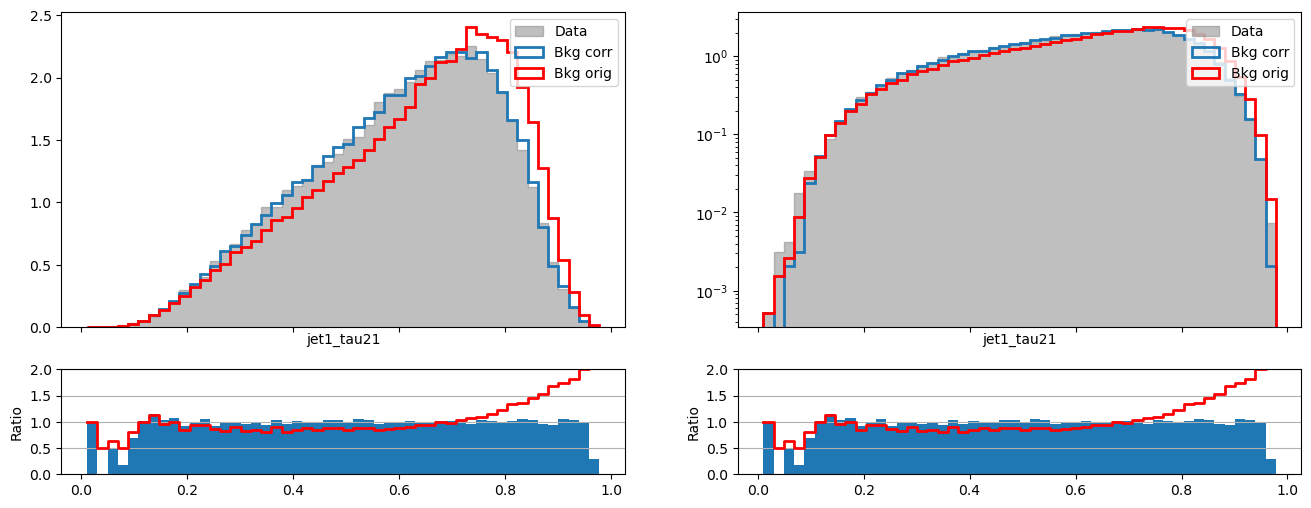

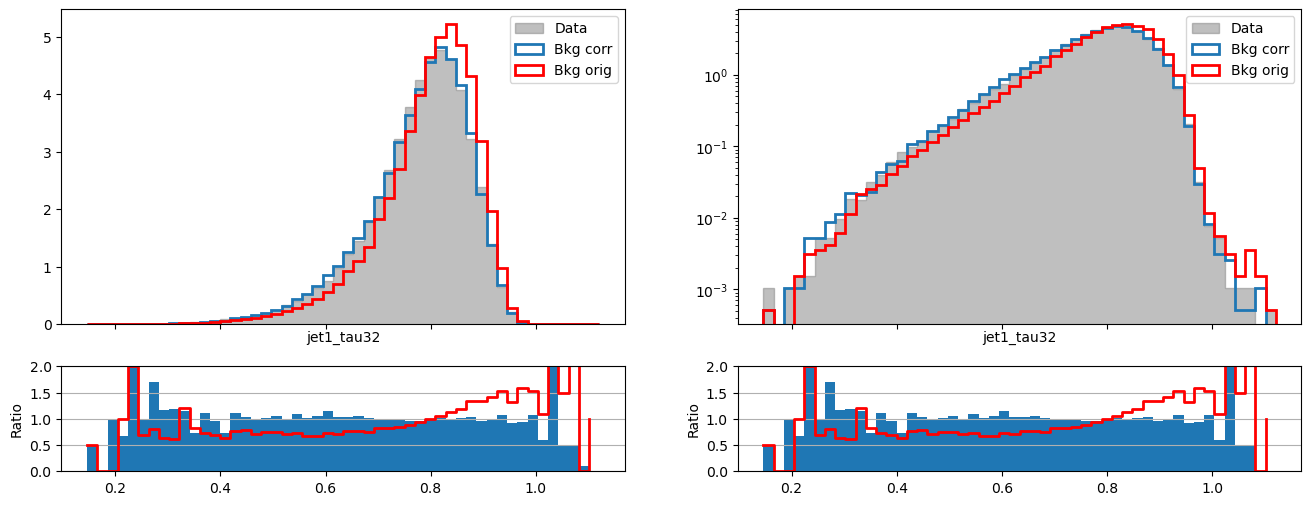

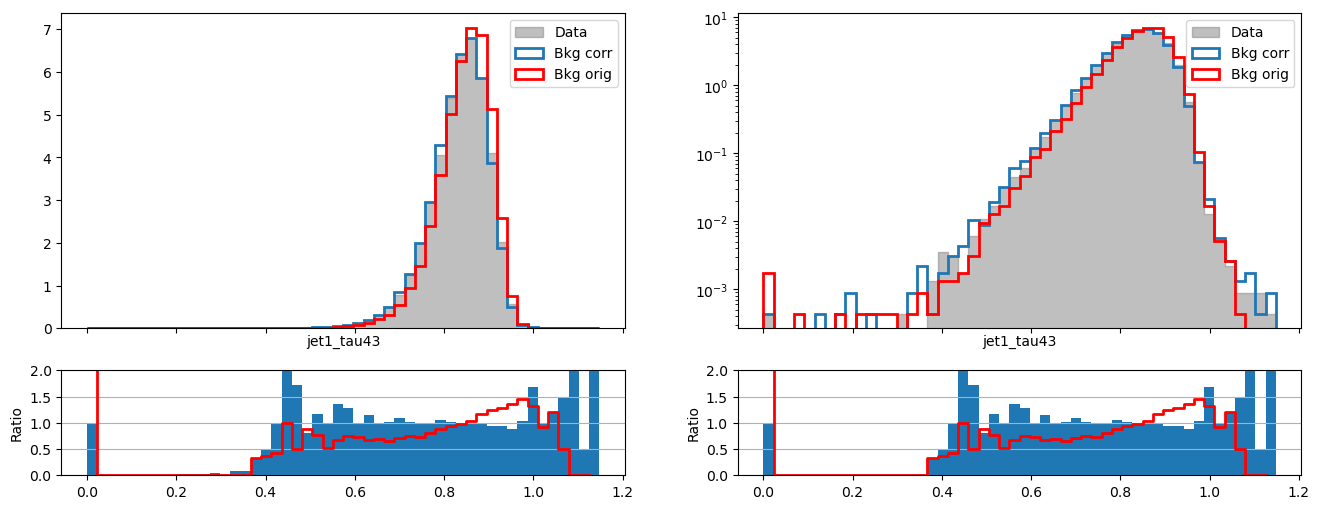

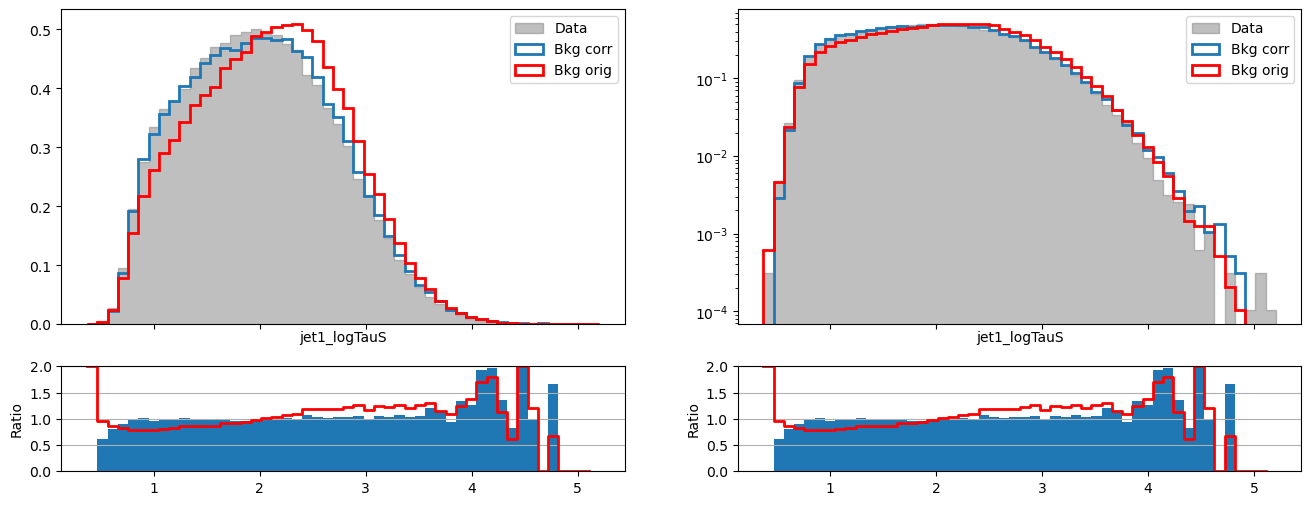

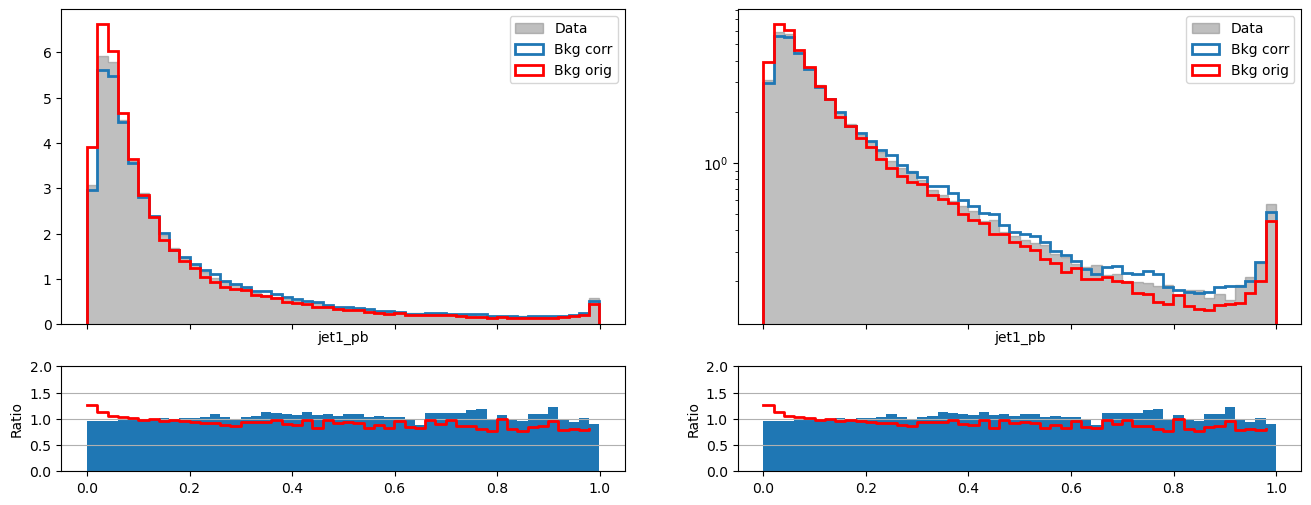

In [55]:
ylim=[0,2]
ytick=np.arange(0,2.5,0.5)

for v in variables:
    plt.subplots(figsize=(16,6),nrows=2,ncols=2,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    plt.subplot(221)
    h1,bins,_ = plt.hist(data[v],bins=50,histtype='step',density=True,label='Data',color='gray',fill=True,alpha=0.5)
    h2,bins,_ = plt.hist(bkg_corr[v],bins=bins,histtype='step',density=True,label='Bkg corr',color='C0',linewidth=2)
    h3,bins,_ = plt.hist(bkg_old[v],bins=bins,histtype='step',density=True,label='Bkg orig',color='red',linewidth=2)
    plt.legend()
    plt.xlabel(v)
    plt.subplot(223)
    w = bins[1]-bins[0]
    c = (bins[1:]+bins[:-1])/2
    h = np.divide(h2,h1,where=h1>0)
    plt.bar(x=c,height=h,width=w,align='center',color="C0")
    h = np.divide(h3,h1,where=h1>0)
    plt.step(x=bins[:-1],y=h,where='post',color="red",linewidth=2)
    #plt.xlim([-3,3])
    plt.ylim(ylim)
    plt.yticks(ytick)
    plt.grid(axis='y')
    plt.ylabel("Ratio")
    plt.subplot(222)
    h1,bins,_ = plt.hist(data[v],bins=bins,histtype='step',density=True,label='Data',color='gray',fill=True,alpha=0.5)
    h2,bins,_ = plt.hist(bkg_corr[v],bins=bins,histtype='step',density=True,label='Bkg corr',color='C0',linewidth=2)
    h3,bins,_ = plt.hist(bkg_old[v],bins=bins,histtype='step',density=True,label='Bkg orig',color='red',linewidth=2)
    plt.yscale('log')
    plt.legend()
    plt.xlabel(v)
    plt.subplot(224)
    w = bins[1]-bins[0]
    c = (bins[1:]+bins[:-1])/2
    h = np.divide(h2,h1,where=h1>0)
    plt.bar(x=c,height=h,width=w,align='center',color="C0")
    h = np.divide(h3,h1,where=h1>0)
    plt.step(x=bins[:-1],y=h,where='post',color="red",linewidth=2)
    #plt.xlim([-3,3])
    plt.ylim(ylim)
    plt.yticks(ytick)
    plt.grid(axis='y')
    plt.ylabel("Ratio")
    
    plt.savefig(f"dataMC_plots/MCtoData_jet1_sideband_{v}.pdf")

In [78]:
d = np.concatenate([data[v] for v in variables],axis=1)
b = np.concatenate([bkg_corr[v] for v in variables],axis=1)
bo = np.concatenate([bkg_old[v] for v in variables],axis=1)

In [79]:
cd = np.corrcoef(d,rowvar=False)
cb = np.corrcoef(b,rowvar=False)
cbo = np.corrcoef(bo,rowvar=False)
from matplotlib.colors import Normalize, LogNorm

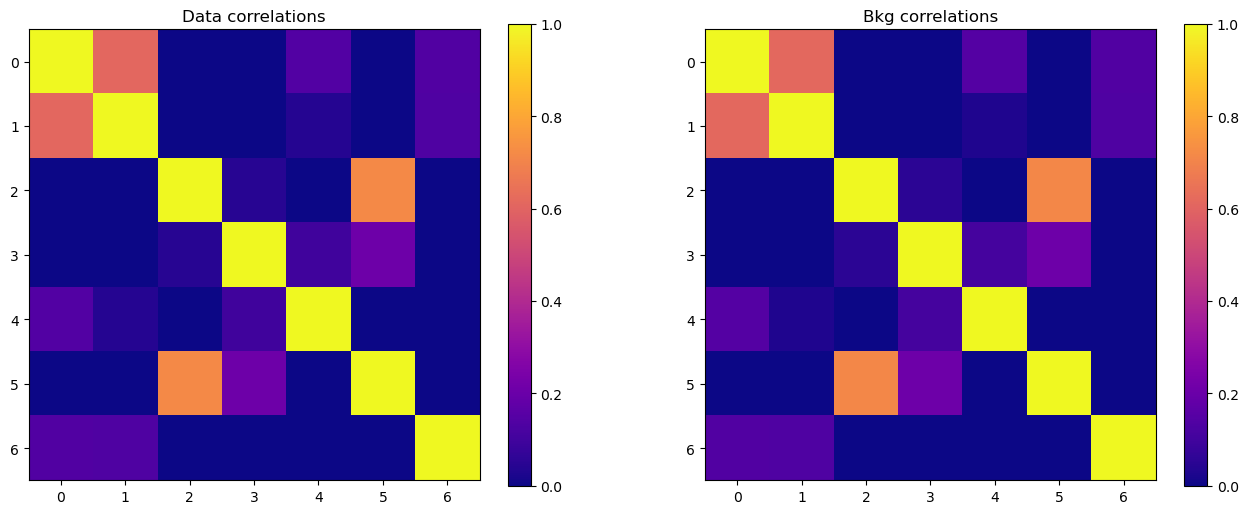

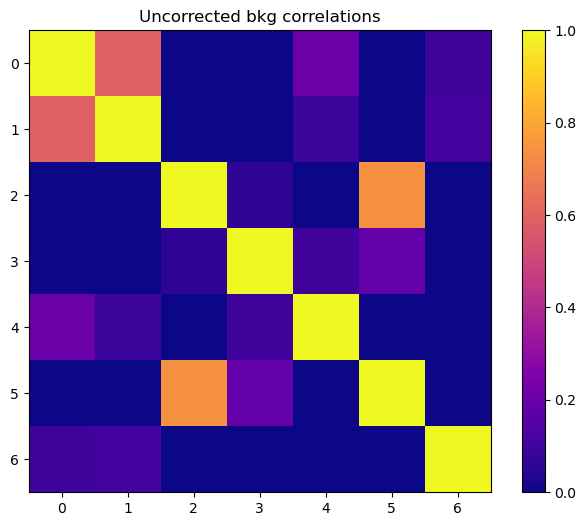

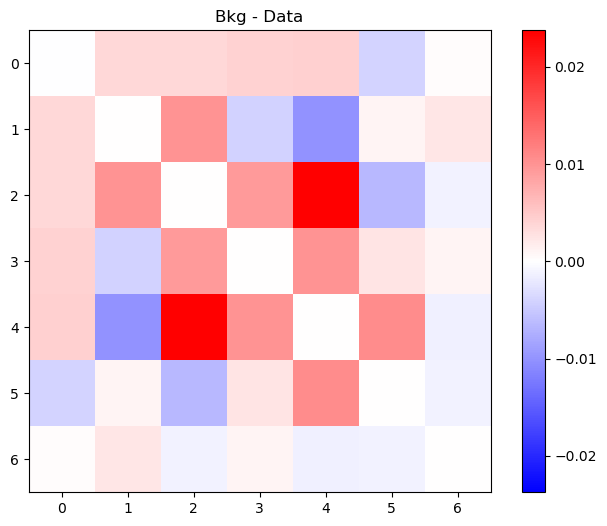

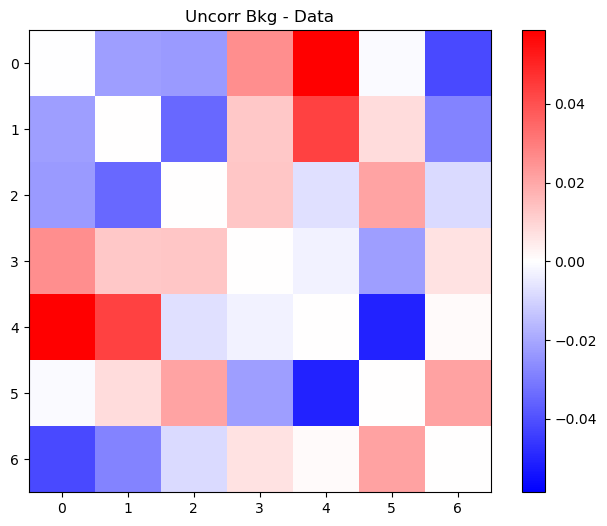

In [83]:
plt.figure(figsize=(16,6))
plt.subplot(121)
norm = Normalize(vmin=0,vmax=1)
plt.imshow(cd,norm=norm,cmap='plasma')
plt.colorbar()
plt.title("Data correlations")
plt.subplot(122)
plt.imshow(cb,norm=norm,cmap='plasma')
plt.colorbar()
plt.title('Bkg correlations')
plt.savefig('dataMC_plots/data_vs_bkg_correlations_jet1_cond-npf.pdf')

plt.figure(figsize=(8,6))
norm = Normalize(vmin=0,vmax=1)
plt.imshow(cbo,norm=norm,cmap='plasma')
plt.colorbar()
plt.title("Uncorrected bkg correlations")
plt.savefig('dataMC_plots/uncorr_bkg_correlations_jet1_cond-npf.pdf')

plt.figure(figsize=(8,6))
diff = cb-cd
dmax = np.max(np.abs(diff))
norm=Normalize(vmin=-dmax,vmax=dmax)
plt.imshow(diff,norm=norm,cmap='bwr')
plt.colorbar()
plt.title("Bkg - Data")
plt.savefig('dataMC_plots/diff_data_vs_bkg_correlations_jet1_cond-npf.pdf')

plt.figure(figsize=(8,6))
diff = cbo-cd
dmax = np.max(np.abs(diff))
norm=Normalize(vmin=-dmax,vmax=dmax)
plt.imshow(diff,norm=norm,cmap='bwr')
plt.colorbar()
plt.title("Uncorr Bkg - Data")
plt.savefig('dataMC_plots/diff_data_vs_uncorr_bkg_correlations_jet1_cond-npf.pdf')